In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import torch
from sklearn.model_selection import train_test_split
# import patpy
# from patpy.tl import associate_embedding_with_covariates
# from patpy.pl import embedding_covariate_heatmap
import scanpy as sc

# import sampleclr
# from sampleclr.utils import (
#     get_sample_representations_from_adata,
#     _compute_eigenvector_centrality,
#     plot_losses,
# )

In [2]:
HPCA_DIABETES_PATH = "workspace/hpca/hpca_downstream/julia_concat_objects/T1D_T2D_aab_core_1504.h5ad"
adata = sc.read_h5ad(HPCA_DIABETES_PATH)
adata

AnnData object with n_obs × n_vars = 1212830 × 36807
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top

In [3]:
meta_adata = sc.read_h5ad('workspace/hpca/hpca_downstream/sampleCLR/meta_adata.h5ad')

In [4]:
import os
os.chdir('workspace/hpca/hpca_downstream/Diabetes_Results/')

# try to see leiden clusters and maybe pre diabetes state for t2d?

In [ ]:
sc.tl.leiden(meta_adata, resolution=1.5, key_added="leiden_ft_1.5", neighbors_key="neighbors_sampleclr_ft")
sc.tl.leiden(meta_adata, resolution=0.5, key_added="leiden_ft_0.5", neighbors_key="neighbors_sampleclr_ft")
sc.tl.leiden(meta_adata, resolution=0.75, key_added="leiden_ft_0.75", neighbors_key="neighbors_sampleclr_ft")

/tmp/ipykernel_2437355/829507598.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(meta_adata, resolution=1.5, key_added="leiden_ft_1.5", neighbors_key="neighbors_sampleclr_ft")
/tmp/ipykernel_2437355/829507598.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  

In [ ]:
# Count number of each disease per leiden_ft cluster and display as a table
cluster_disease_counts = (
    meta_adata.obs.groupby(['leiden_ft', 'disease'])
    .size()
    .unstack(fill_value=0)
)
cluster_disease_counts

/tmp/ipykernel_2437355/1715206220.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby(['leiden_ft', 'disease'])


disease,healthy,aab,T1D,T2D
leiden_ft,,,,
0,6,18,17,0
1,32,0,0,0
2,27,3,0,1
3,20,0,3,6
4,23,0,0,4
5,17,0,5,0
6,9,0,0,7
7,6,0,0,0


In [ ]:
# Count number of each disease per leiden_ft cluster and display as a table
cluster_disease_counts = (
    meta_adata.obs.groupby(['leiden_ft_1.5', 'disease'])
    .size()
    .unstack(fill_value=0)
)
cluster_disease_counts.sort_values(by=['aab', 'T1D', 'T2D'], ascending=False)

/tmp/ipykernel_2437355/756408399.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby(['leiden_ft_1.5', 'disease'])


disease,healthy,aab,T1D,T2D
leiden_ft_1.5,,,,
9,0,10,0,0
0,6,6,16,0
5,16,4,0,0
4,14,1,6,0
2,13,0,3,6
11,3,0,0,5
6,14,0,0,4
10,7,0,0,2
7,12,0,0,1


In [30]:
# Count number of each disease per leiden_ft cluster and display as a table
cluster_disease_counts = (
    meta_adata.obs.groupby(['leiden_ft_0.5', 'disease'])
    .size()
    .unstack(fill_value=0)
)
cluster_disease_counts.sort_values(by=['aab', 'T1D', 'T2D'], ascending=False)

/tmp/ipykernel_2437355/1070430526.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby(['leiden_ft_0.5', 'disease'])


disease,healthy,aab,T1D,T2D
leiden_ft_0.5,,,,
1,23,21,22,0
0,64,0,3,17
2,53,0,0,1


In [31]:
# Count number of each disease per leiden_ft cluster and display as a table
cluster_disease_counts = (
    meta_adata.obs.groupby(['leiden_ft_0.75', 'disease'])
    .size()
    .unstack(fill_value=0)
)
cluster_disease_counts.sort_values(by=['aab', 'T1D', 'T2D'], ascending=False)

/tmp/ipykernel_2437355/851520022.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby(['leiden_ft_0.75', 'disease'])


disease,healthy,aab,T1D,T2D
leiden_ft_0.75,,,,
1,7,21,17,0
5,16,0,5,0
4,10,0,3,13
3,24,0,0,4
2,35,0,0,1
0,48,0,0,0


In [ ]:
meta_adata.obs['disease_root_ixs'] = meta_adata.obs.disease.astype(str) + '_' + meta_adata.obs.root_ixs.astype(str)
meta_adata.obs['disease_root_ixs'] = meta_adata.obs.disease_root_ixs.replace('_nan', '', regex=True)
meta_adata.obs['disease_root_ixs_filtered'] = meta_adata.obs.disease_root_ixs.replace('healthy', np.nan)

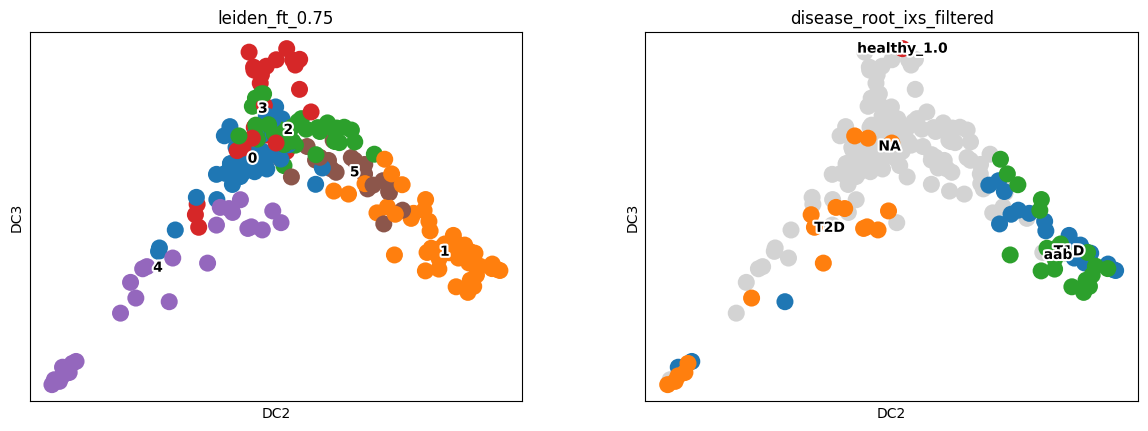

In [ ]:
sc.pl.diffmap(meta_adata, color=['leiden_ft_0.75', 'disease_root_ixs_filtered'], components=['2,3',], size=600, legend_loc='on data', legend_fontoutline=3)

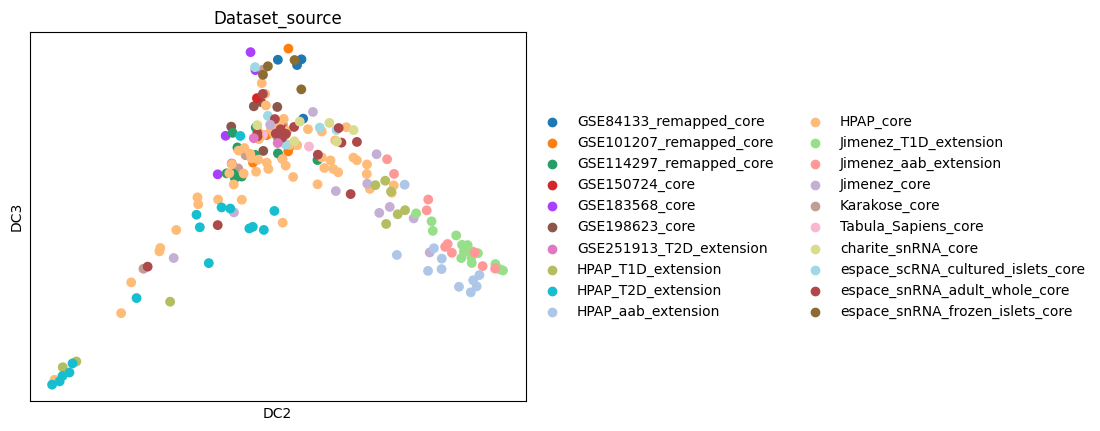

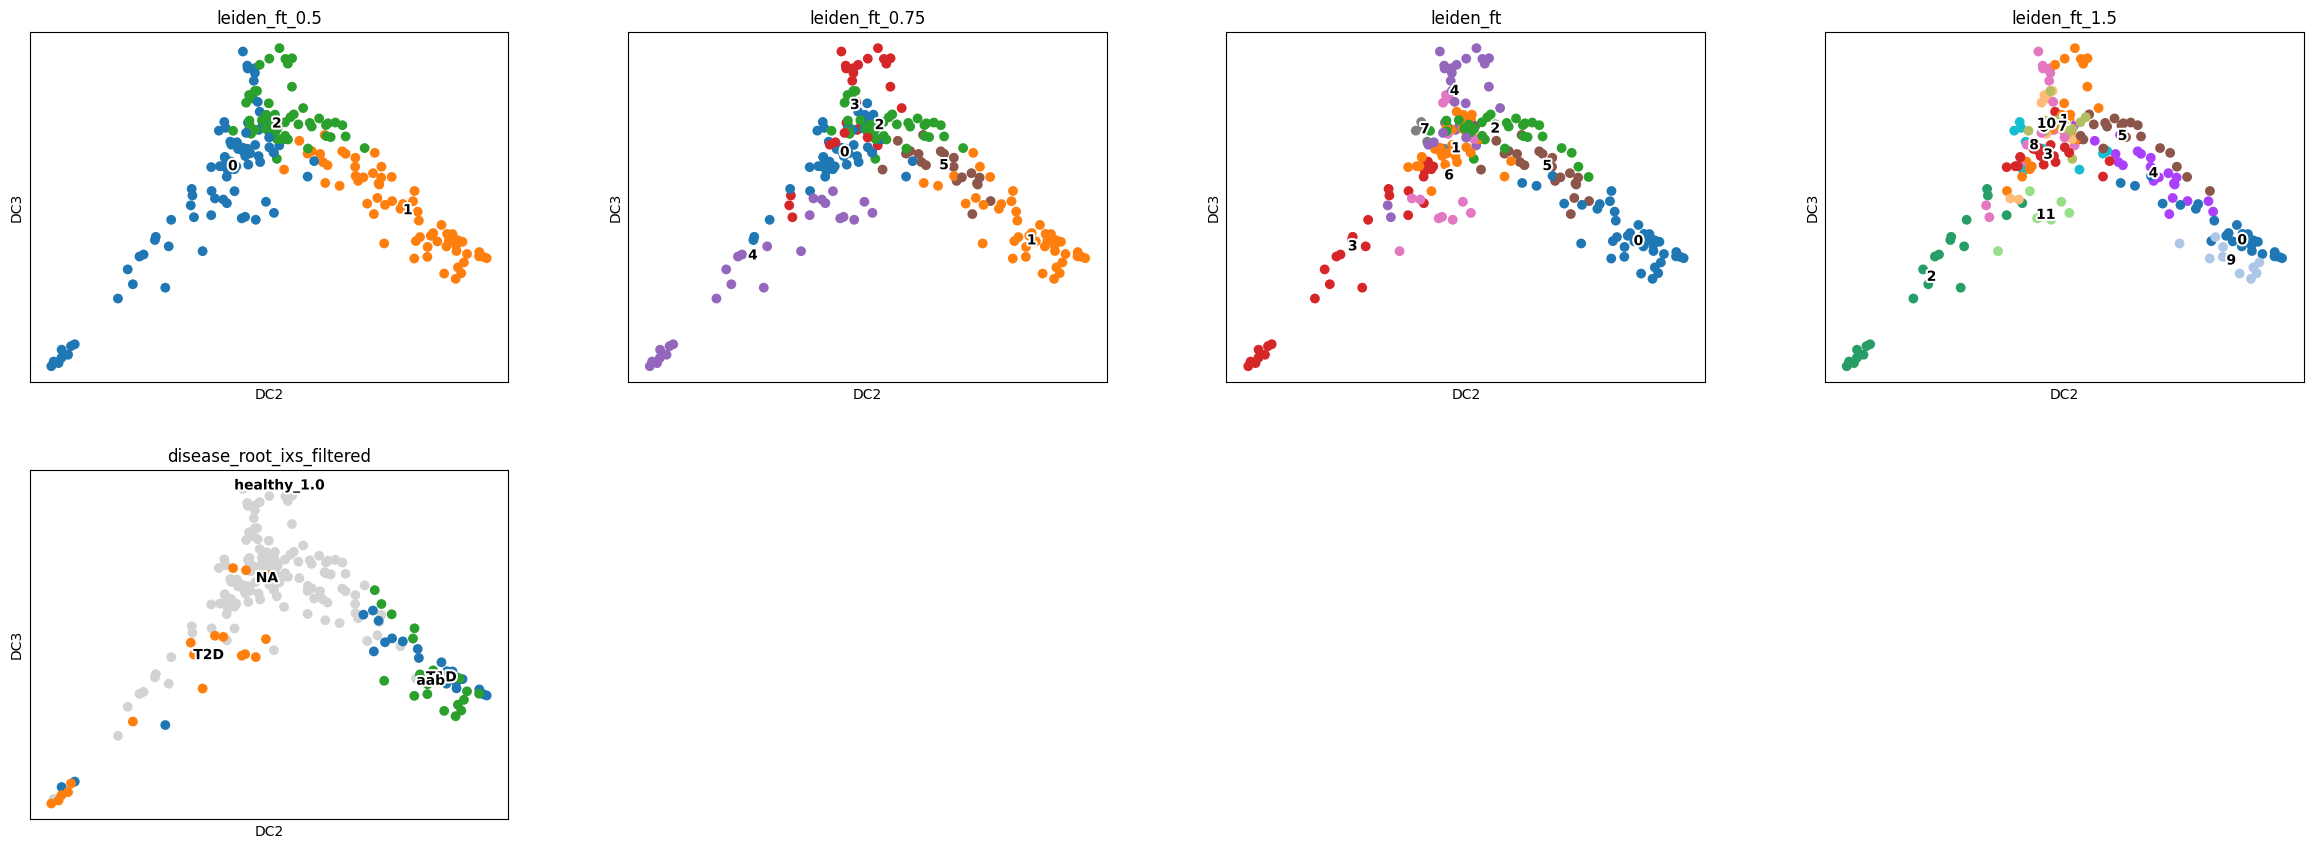

In [ ]:
sc.pl.diffmap(meta_adata, color=['Dataset_source'], components=['2,3',], size=200, legend_fontoutline=3)
sc.pl.diffmap(meta_adata, color=['leiden_ft_0.5', 'leiden_ft_0.75', 'leiden_ft', 'leiden_ft_1.5', 'disease_root_ixs_filtered'], components=['2,3',], size=200, legend_loc='on data', legend_fontoutline=3)

In [ ]:
celltypes = meta_adata.var_names[meta_adata.var_names.str.contains('Alpha|Beta')].tolist()
expr_df = meta_adata.to_df()[celltypes].copy()
expr_df_raw = meta_adata.to_df(layer='composition_raw')[celltypes].copy()
expr_df['leiden_ft_0.75'] = meta_adata.obs['leiden_ft_0.75'].values
expr_df_raw['leiden_ft_0.75'] = meta_adata.obs['leiden_ft_0.75'].values

melted = expr_df.melt(id_vars='leiden_ft_0.75', var_name='CellType', value_name='Expression')
melted_raw = expr_df_raw.melt(id_vars='leiden_ft_0.75', var_name='CellType', value_name='Expression')
melted = melted.dropna(subset=['leiden_ft_0.75'])
melted_raw = melted_raw.dropna(subset=['leiden_ft_0.75'])

/tmp/ipykernel_2437355/2349964205.py:5: UserWarning: 
The palette list has fewer values (9) than needed (16) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
/tmp/ipykernel_2437355/2349964205.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='right', fontsize=12)
/tmp/ipykernel_2437355/2349964205.py:5: UserWarning: 
The palette list has fewer values (9) than needed (19) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
/tmp/ipykernel_2437355/2349964205.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='right', fontsize=12)


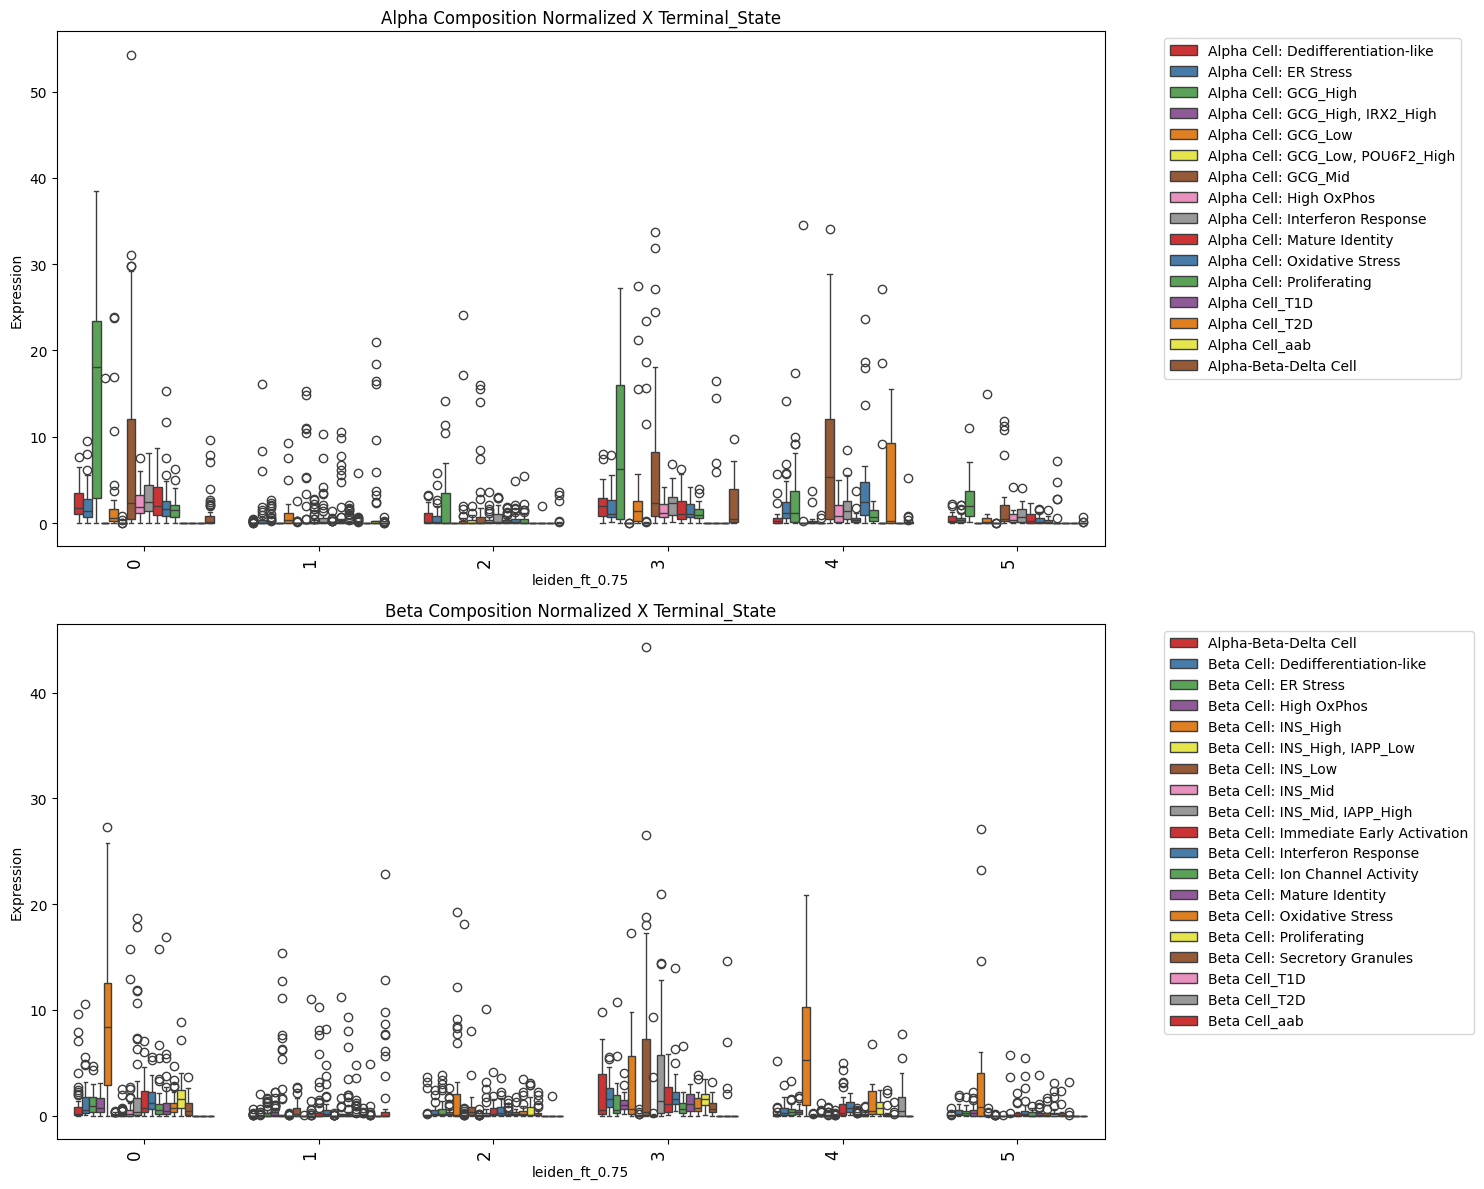

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(2,1, figsize=(15,12))
for i, celltype in enumerate(['Alpha', 'Beta']):
    melted_subset = melted[melted['CellType'].str.contains(celltype)]
    sns.boxplot(
        data=melted_subset,
        x="leiden_ft_0.75",
        y="Expression",
        hue="CellType", width=0.8, linewidth=1, fliersize=6,
        ax=axes[i], palette=sns.color_palette("Set1")
    )
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='right', fontsize=12)
    axes[i].set_title(f"{celltype} Composition Normalized X Terminal_State")
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
fig.savefig("boxplots_normalized_composition.svg", dpi=300, format='svg')
fig.savefig("boxplots_normalized_composition.png", dpi=300)
plt.show()


/tmp/ipykernel_2437355/1547460684.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='right', fontsize=12)
/tmp/ipykernel_2437355/1547460684.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='right', fontsize=12)


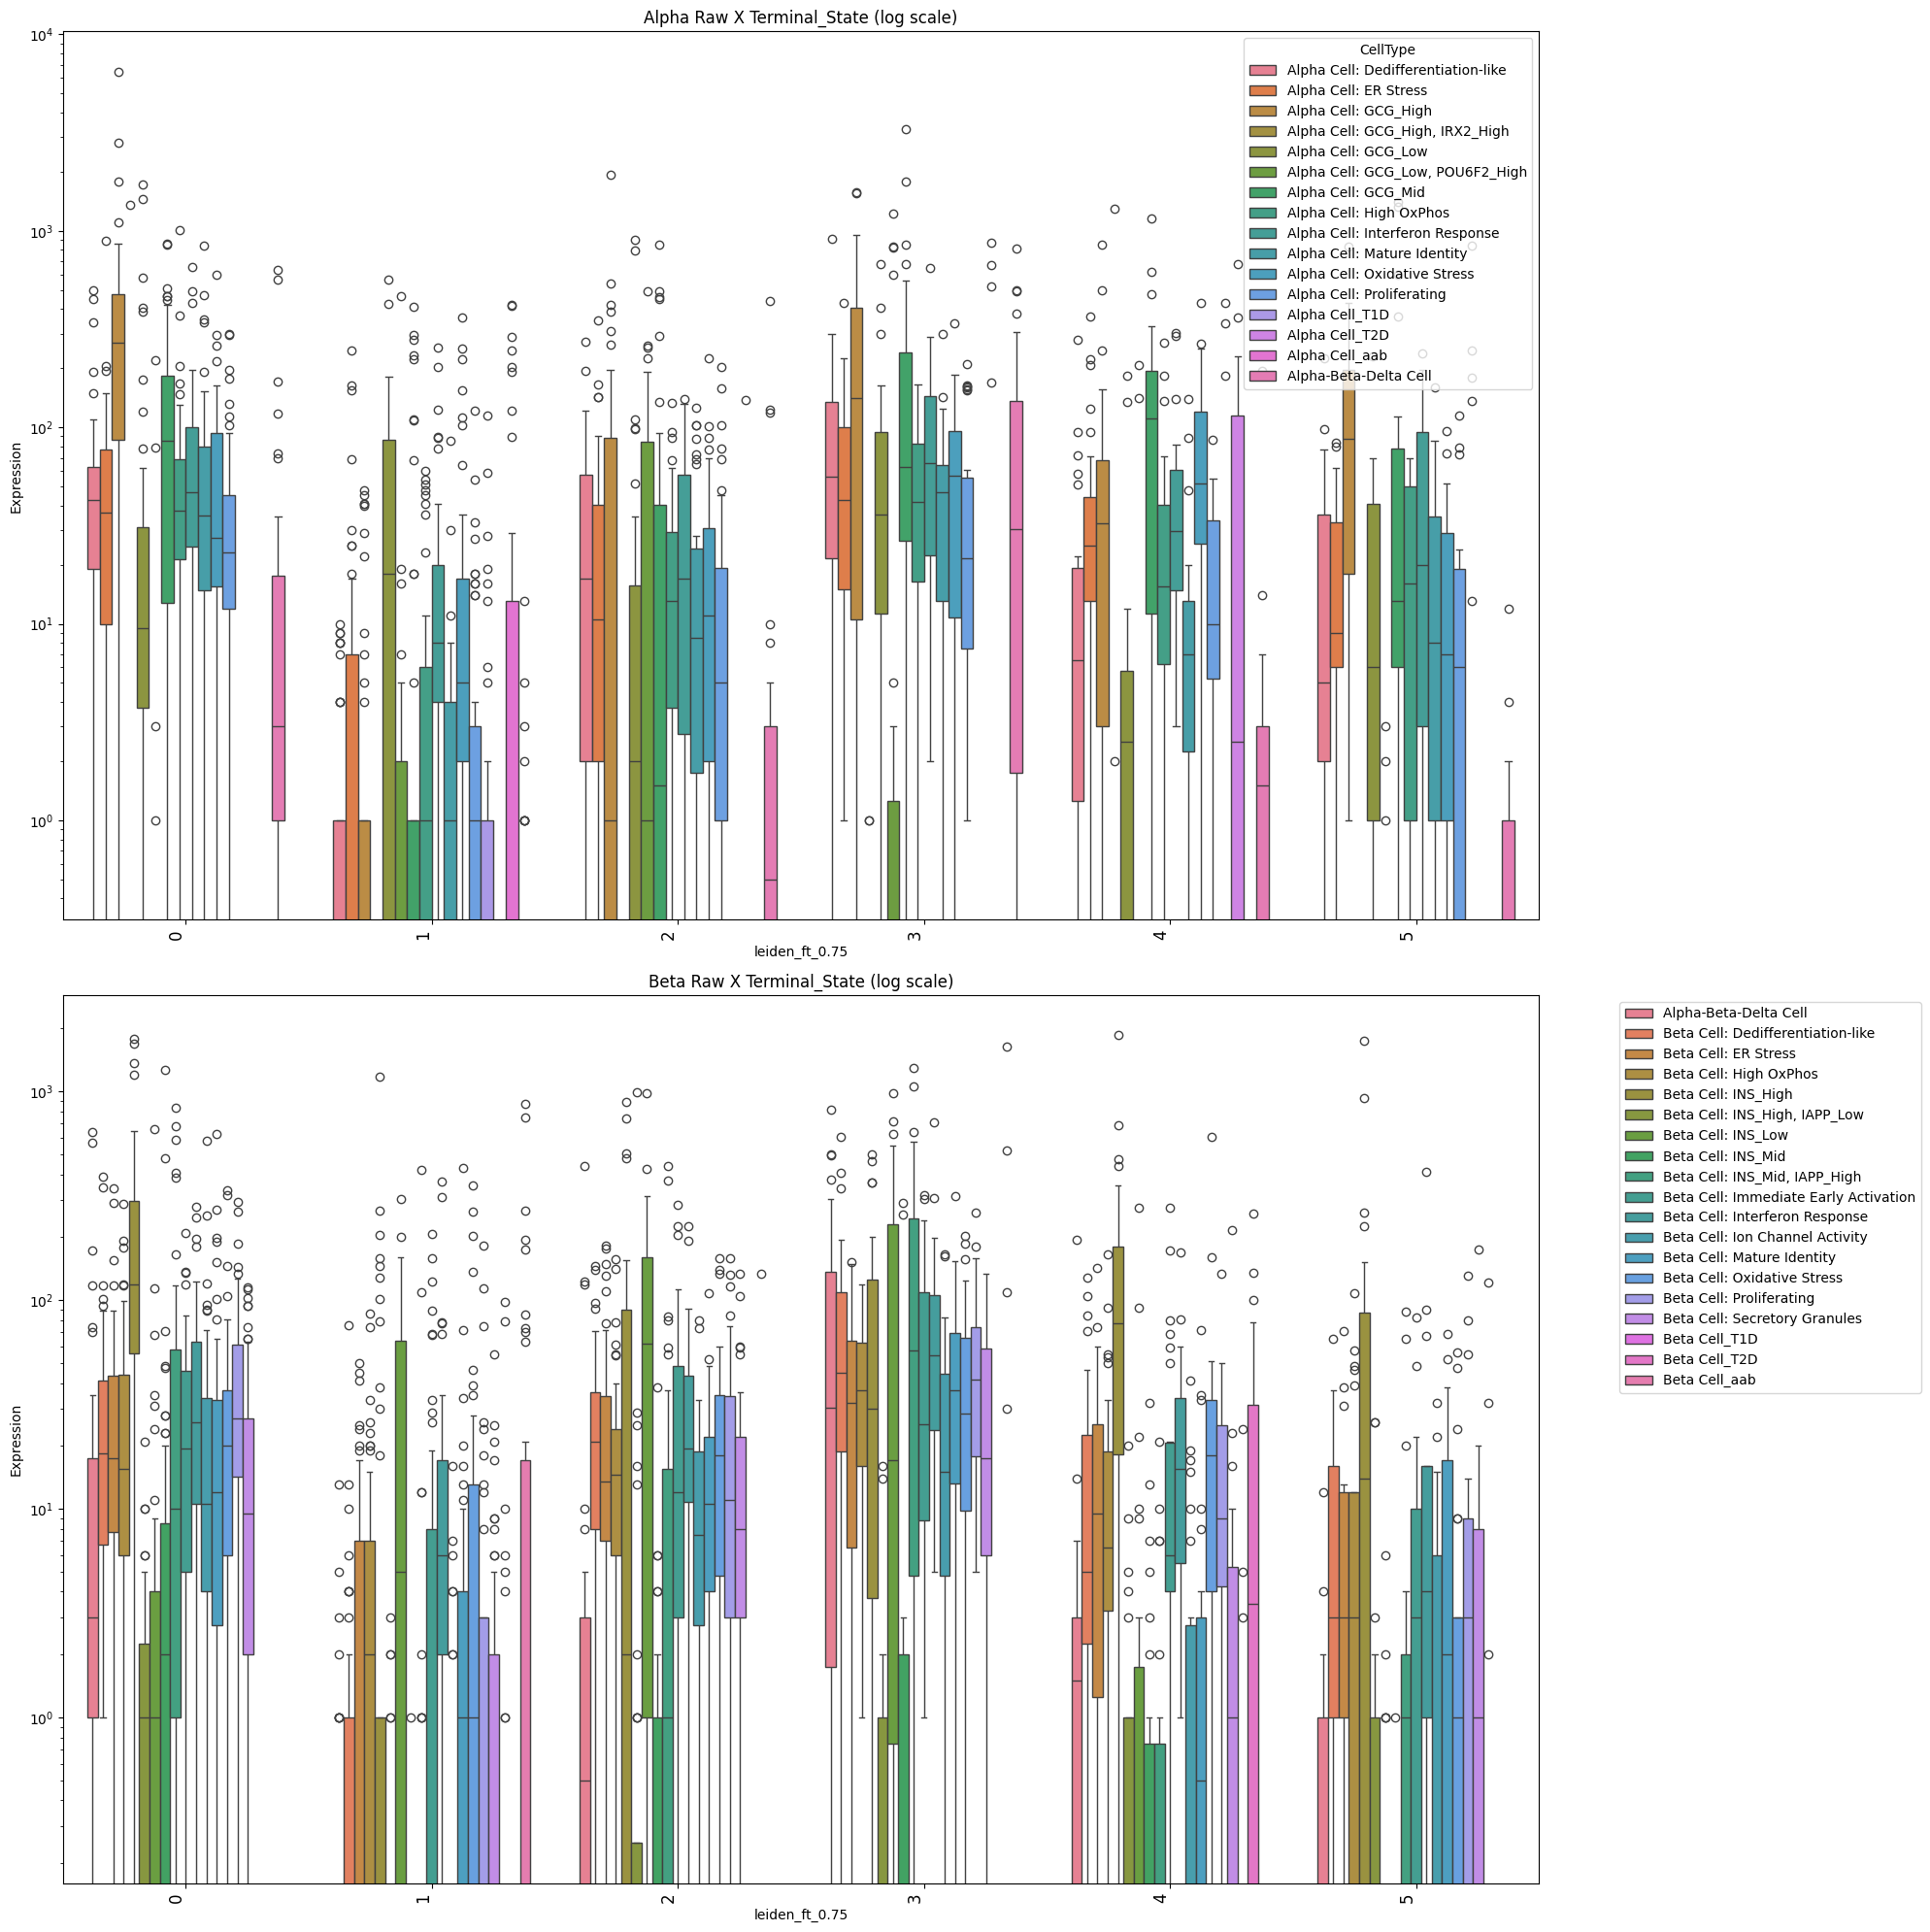

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(20, 20))
for i, celltype in enumerate(['Alpha', 'Beta']):
    melted_subset_raw = melted_raw[melted_raw['CellType'].str.contains(celltype)]
    sns.boxplot(
        data=melted_subset_raw,
        x="leiden_ft_0.75",
        y="Expression",
        hue="CellType",
        ax=axes[i]
    )
    axes[i].set_yscale('log')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='right', fontsize=12)
    axes[i].set_title(f"{celltype} Raw X Terminal_State (log scale)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
fig.savefig("boxplots_raw_composition.svg", dpi=300, format='svg')
plt.show()


In [ ]:
from itertools import combinations

pairs = []
sources = obs["disease"].dropna().unique()

for a, b in combinations(sources, 2):
    x = obs.loc[obs["disease"] == a, "palantir_pseudotime"]
    y = obs.loc[obs["disease"] == b, "palantir_pseudotime"]

    stat, p = stats.mannwhitneyu(x, y, alternative="two-sided")
    pairs.append({
        "group1": a,
        "group2": b,
        "n1": len(x),
        "n2": len(y),
        "median1": x.median(),
        "median2": y.median(),
        "delta_median": y.median() - x.median(),
        "pval": p,
    })

pairwise_dpt = pd.DataFrame(pairs)
pairwise_dpt["padj"] = multipletests(pairwise_dpt["pval"], method="fdr_bh")[1]
pairwise_dpt.sort_values("padj")

,group1,group2,n1,n2,median1,median2,delta_median,pval,padj
0,healthy,T1D,140,25,0.202732,0.671491,0.468759,8.331607e-13,4.998964e-12
2,healthy,aab,140,21,0.202732,0.648749,0.446016,1.924838e-10,5.774513e-10
1,healthy,T2D,140,18,0.202732,0.601832,0.399099,3.152034e-07,6.304067e-07
4,T1D,aab,25,21,0.671491,0.648749,-0.022742,1.517360e-01,2.276040e-01
3,T1D,T2D,25,18,0.671491,0.601832,-0.069659,3.432290e-01,4.118748e-01
5,T2D,aab,18,21,0.601832,0.648749,0.046917,9.214548e-01,9.214548e-01


In [ ]:
meta_adata.obs.groupby('Dataset_source')['age_from_hsapdv'].unique()

/tmp/ipykernel_2437355/2222659133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby('Dataset_source')['age_from_hsapdv'].unique()


Dataset_source
GSE84133_remapped_core               ['(30.0, 40.0)', '(15.0, 20.0)', '(50.0, 60.0)...
GSE101207_remapped_core              ['(40.0, 50.0)', '(60.0, 70.0)', '(50.0, 60.0)...
GSE114297_remapped_core              ['(30.0, 40.0)', '(20.0, 30.0)', '(50.0, 60.0)...
GSE150724_core                       ['(50.0, 60.0)']
Categories (12, object): ['(0...
GSE183568_core                       ['(50.0, 60.0)', '(60.0, 70.0)', '(30.0, 40.0)...
GSE198623_core                       ['(20.0, 30.0)', '(60.0, 70.0)', '(70.0, 80.0)...
GSE251913_T2D_extension              [NaN]
Categories (12, object): ['(0.0, 1.0)', ...
HPAP_T1D_extension                   [NaN]
Categories (12, object): ['(0.0, 1.0)', ...
HPAP_T2D_extension                   [NaN]
Categories (12, object): ['(0.0, 1.0)', ...
HPAP_aab_extension                   [NaN]
Categories (12, object): ['(0.0, 1.0)', ...
HPAP_core                            ['(20.0, 30.0)', '(5.0, 15.0)', '(30.0, 40.0)'...
Jimenez_T1D_extension       

In [ ]:
age_bins = [0, 1, 5, 15, 20, 30, 40, 50, 60, 70, 80, np.inf]
age_labels = [
    "(0.0, 1.0)",
    "(1.0, 5.0)",
    "(5.0, 15.0)",
    "(15.0, 20.0)",
    "(20.0, 30.0)",
    "(30.0, 40.0)",
    "(40.0, 50.0)",
    "(50.0, 60.0)",
    "(60.0, 70.0)",
    "(70.0, 80.0)",
    "(80.0, 150.0)"
]

meta_adata.obs["age_from_age_binned"] = pd.cut(
    meta_adata.obs["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

meta_adata.obs["age_from_hsapdv_harmonized"] = meta_adata.obs["age_from_hsapdv"].astype("object")
meta_adata.obs["age_from_hsapdv_harmonized"] = meta_adata.obs["age_from_hsapdv_harmonized"].where(
    meta_adata.obs["age_from_hsapdv_harmonized"].notna(),
    meta_adata.obs["age_from_age_binned"].astype("object")
)

In [ ]:
meta_adata.obs.head()

,Dataset,sample_id,alignment_software,assay_ontology_term_id,institute,library_id,condition,manner_of_death,reference_genome,sample_source,...,age_from_age_binned,age_from_hsapdv_harmonized,age_from_hsapdv_harmonized_binned,age_category,leiden_ft_1.5,leiden_ft_0.5,leiden_ft_0.75,disease_root_ixs_filtered,HbA1c_category,iroot
Dataset_ID,,,,,,,,,,,,,,,,,,,,,
GSE101207_remapped_core : Non_diabetic_donor_6,GSE101207_remapped,SAMN08051215,STAR,EFO:0008722,NaN,SRX3413848,NaN,unknown,GRCh37,organ donor,...,NaN,"(40.0, 50.0)",6.0,Middle-Aged Adult (40–60 years),3,0,0,NaN,normal,77
GSE101207_remapped_core : Diabetic_donor_2,GSE101207_remapped,SAMN07343857,STAR,EFO:0008722,NaN,SRX2996340,NaN,unknown,GRCh37,organ donor,...,NaN,"(60.0, 70.0)",8.0,Older Adult (≥60 years),3,0,0,NaN,normal,77
GSE101207_remapped_core : Diabetic_donor_3,GSE101207_remapped,SAMN08051214,STAR,EFO:0008722,NaN,SRX3413849,NaN,unknown,GRCh37,organ donor,...,NaN,"(50.0, 60.0)",7.0,Middle-Aged Adult (40–60 years),6,0,3,NaN,high,77
GSE101207_remapped_core : Non_diabetic_donor_5,GSE101207_remapped,SAMN07343859,STAR,EFO:0008722,NaN,SRX2996338,NaN,unknown,GRCh37,organ donor,...,NaN,"(20.0, 30.0)",4.0,Young Adult (20–40 years),1,2,3,healthy_1.0,normal,77
GSE101207_remapped_core : Non_diabetic_donor_4,GSE101207_remapped,SAMN07343860,STAR,EFO:0008722,NaN,SRX2996337,NaN,unknown,GRCh37,organ donor,...,NaN,"(50.0, 60.0)",7.0,Middle-Aged Adult (40–60 years),6,0,3,NaN,normal,77


In [ ]:
meta_adata.obs.groupby('Dataset_source')['age_from_hsapdv_harmonized'].unique()

/tmp/ipykernel_2437355/3860918887.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby('Dataset_source')['age_from_hsapdv_harmonized'].unique()


Dataset_source
GSE84133_remapped_core                      [(30.0, 40.0), (15.0, 20.0), (50.0, 60.0)]
GSE101207_remapped_core              [(40.0, 50.0), (60.0, 70.0), (50.0, 60.0), (20...
GSE114297_remapped_core              [(30.0, 40.0), (20.0, 30.0), (50.0, 60.0), (40...
GSE150724_core                                                          [(50.0, 60.0)]
GSE183568_core                       [(50.0, 60.0), (60.0, 70.0), (30.0, 40.0), (5....
GSE198623_core                              [(20.0, 30.0), (60.0, 70.0), (70.0, 80.0)]
GSE251913_T2D_extension                                   [(60.0, 70.0), (50.0, 60.0)]
HPAP_T1D_extension                   [(5.0, 15.0), (1.0, 5.0), (20.0, 30.0), (15.0,...
HPAP_T2D_extension                          [(40.0, 50.0), (50.0, 60.0), (30.0, 40.0)]
HPAP_aab_extension                           [(20.0, 30.0), (15.0, 20.0), (5.0, 15.0)]
HPAP_core                            [(20.0, 30.0), (5.0, 15.0), (30.0, 40.0), (15....
Jimenez_T1D_extension       

In [ ]:
meta_adata.obs.groupby('Dataset_source')['sex_ontology_term_id'].unique()

/tmp/ipykernel_2437355/1937484582.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby('Dataset_source')['sex_ontology_term_id'].unique()


Dataset_source
GSE84133_remapped_core               ['PATO:0000384', 'PATO:0000383']
Categories (2...
GSE101207_remapped_core              ['PATO:0000384', 'PATO:0000383']
Categories (2...
GSE114297_remapped_core              ['PATO:0000383', 'PATO:0000384']
Categories (2...
GSE150724_core                       ['PATO:0000384']
Categories (2, object): ['PAT...
GSE183568_core                       ['PATO:0000384', 'PATO:0000383']
Categories (2...
GSE198623_core                       ['PATO:0000383', 'PATO:0000384']
Categories (2...
GSE251913_T2D_extension              [NaN]
Categories (2, object): ['PATO:0000383',...
HPAP_T1D_extension                   [NaN]
Categories (2, object): ['PATO:0000383',...
HPAP_T2D_extension                   [NaN]
Categories (2, object): ['PATO:0000383',...
HPAP_aab_extension                   [NaN]
Categories (2, object): ['PATO:0000383',...
HPAP_core                            ['PATO:0000384', 'PATO:0000383']
Categories (2...
Jimenez_T1D_extension       

In [ ]:
meta_adata.obs.groupby('Dataset_source')['BMI'].unique()

/tmp/ipykernel_2437355/2392284645.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby('Dataset_source')['BMI'].unique()


Dataset_source
GSE84133_remapped_core                                                           [nan]
GSE101207_remapped_core                           [34.6, 28.1, 35.6, 30.8, 22.0, 34.4]
GSE114297_remapped_core              [24.9, 30.8, 21.2, 30.0, 26.5, 23.6, 23.0, 23....
GSE150724_core                                                                   [nan]
GSE183568_core                                        [22.4, 32.3, 18.5, 34.76, 24.13]
GSE198623_core                                          [23.0, 22.0, 19.6, 22.3, 29.2]
GSE251913_T2D_extension                                                   [34.9, 31.0]
HPAP_T1D_extension                   [13.2, 21.4, 17.3, 16.3, 27.9, 16.98, 15.42, 1...
HPAP_T2D_extension                   [45.49, 30.49, 29.26, 38.27, 37.47, 17.09, 28....
HPAP_aab_extension                   [29.8, 24.3, 28.6, 18.34, 24.07, 26.2, 37.2, 2...
HPAP_core                            [29.8, 13.2, 21.4, 34.7, 24.3, 17.3, 28.6, 16....
Jimenez_T1D_extension       

In [ ]:
obs = meta_adata.obs.copy()
covs = ["age_from_hsapdv_harmonized", "sex_ontology_term_id", "BMI", "BMI_category", "HbA1c", "suspension_type", "Dataset_source"]

for c in ["bmi", "hba1c"]:
    if c in obs.columns:
        obs[c] = pd.to_numeric(obs[c], errors="coerce")

available_covs = [c for c in covs if c in obs.columns]

available_covs

['age_from_hsapdv_harmonized',
 'sex_ontology_term_id',
 'BMI',
 'BMI_category',
 'HbA1c',
 'suspension_type',
 'Dataset_source']

In [ ]:
if "age_from_hsapdv_harmonized" in obs.columns:
    def get_bin_midpoint(age_bin):
        if isinstance(age_bin, tuple) or (isinstance(age_bin, str) and "," in age_bin):
            if isinstance(age_bin, str):
                age_bin = age_bin.strip("()").replace("nan", "NaN")
                try:
                    left, right = age_bin.split(",")
                    left = float(left)
                    right = float(right)
                except Exception:
                    return np.nan
            else:
                left, right = age_bin
            return (float(left) + float(right)) / 2
        else:
            try:
                return float(age_bin)
            except Exception:
                return np.nan

    age_numeric = obs["age_from_hsapdv_harmonized"].apply(get_bin_midpoint)
    custom_bins = [0, 1, 5, 15, 20, 30, 40, 50, 60, 70, 80, 150]
    custom_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

    binned = pd.cut(age_numeric, bins=custom_bins, labels=custom_labels, include_lowest=True, right=True)
    binned = binned.astype(float)
    binned[binned == -1] = np.nan
    obs['age_from_hsapdv_harmonized_binned'] = binned

In [ ]:
obs["disease"] = obs["disease"].astype("category")
obs["disease"] = obs["disease"].cat.reorder_categories(["healthy", "aab", "T1D", "T2D"],ordered=True)
age_group_labels = [
    "Pediatric",                     # Bins 0-2: 0-15 years
    "Adolescent (5–20 years)",       # Bin 3: 15-20 years
    "Young Adult (20–40 years)",     # Bins 4-5: 20-40 years
    "Middle-Aged Adult (40–60 years)", # Bins 6-7: 40-60 years
    "Older Adult (≥60 years)"        # Bins 8-10: 60-150 years
]
def get_age_category(binned_value):
    if pd.isna(binned_value):
        return np.nan
    try:
        bin_int = int(binned_value)
    except Exception:
        return np.nan
    if bin_int in [0, 1, 2]:
        return age_group_labels[0]
    elif bin_int == 3:
        return age_group_labels[1]
    elif bin_int in [4, 5]:
        return age_group_labels[2]
    elif bin_int in [6, 7]:
        return age_group_labels[3]
    elif bin_int in [8, 9, 10]:
        return age_group_labels[4]
    else:
        return np.nan

obs["age_category"] = obs["age_from_hsapdv_harmonized_binned"].apply(get_age_category)
meta_adata.obs['age_category'] = obs['age_category'].copy()
obs.head()

,Dataset,sample_id,alignment_software,assay_ontology_term_id,institute,library_id,condition,manner_of_death,reference_genome,sample_source,...,age_from_age_binned,age_from_hsapdv_harmonized,age_from_hsapdv_harmonized_binned,age_category,leiden_ft_1.5,leiden_ft_0.5,leiden_ft_0.75,disease_root_ixs_filtered,HbA1c_category,iroot
Dataset_ID,,,,,,,,,,,,,,,,,,,,,
GSE101207_remapped_core : Non_diabetic_donor_6,GSE101207_remapped,SAMN08051215,STAR,EFO:0008722,NaN,SRX3413848,NaN,unknown,GRCh37,organ donor,...,NaN,"(40.0, 50.0)",6.0,Middle-Aged Adult (40–60 years),3,0,0,NaN,normal,77
GSE101207_remapped_core : Diabetic_donor_2,GSE101207_remapped,SAMN07343857,STAR,EFO:0008722,NaN,SRX2996340,NaN,unknown,GRCh37,organ donor,...,NaN,"(60.0, 70.0)",8.0,Older Adult (≥60 years),3,0,0,NaN,normal,77
GSE101207_remapped_core : Diabetic_donor_3,GSE101207_remapped,SAMN08051214,STAR,EFO:0008722,NaN,SRX3413849,NaN,unknown,GRCh37,organ donor,...,NaN,"(50.0, 60.0)",7.0,Middle-Aged Adult (40–60 years),6,0,3,NaN,high,77
GSE101207_remapped_core : Non_diabetic_donor_5,GSE101207_remapped,SAMN07343859,STAR,EFO:0008722,NaN,SRX2996338,NaN,unknown,GRCh37,organ donor,...,NaN,"(20.0, 30.0)",4.0,Young Adult (20–40 years),1,2,3,healthy_1.0,normal,77
GSE101207_remapped_core : Non_diabetic_donor_4,GSE101207_remapped,SAMN07343860,STAR,EFO:0008722,NaN,SRX2996337,NaN,unknown,GRCh37,organ donor,...,NaN,"(50.0, 60.0)",7.0,Middle-Aged Adult (40–60 years),6,0,3,NaN,normal,77


# recompute root cell and redo palantir

In [70]:
!pip install palantir

  Using cached palantir-1.4.4-py3-none-any.whl.metadata (12 kB)
  Using cached mellon-1.7.1-py3-none-any.whl.metadata (4.4 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached jax-0.10.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxopt-0.8.5-py3-none-any.whl.metadata (3.3 kB)
  Using cached jaxlib-0.10.1-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
Using cached palantir-1.4.4-py3-none-any.whl (63 kB)
Using cached mellon-1.7.1-py3-none-any.whl (101 kB)
Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (5.0 MB)
Using cached jax-0.10.1-py3-none-any.whl (3.2 MB)
Using cached jaxlib-0.10.1-cp312-cp312-manylinux_2_27_x86_64.whl (85.8 MB)
Using cached jaxopt-0.8.5-py3-none-any.whl (172 kB)
Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [palan

In [71]:
import scanpy.external as sce
sce.tl.palantir(meta_adata, distances_key="distances_sampleclr_ft")
terminal_states = meta_adata[meta_adata.obs.Source.str.contains('T1D|T2D')].obs_names.tolist()
# meta_adata[meta_adata.obs_names.isin(terminal_states)].obs.Source.value_counts()
palantir_results = sce.tl.palantir_results(meta_adata, early_cell=root_cell, terminal_states=terminal_states,
use_early_cell_as_start=True)
meta_adata.obs['palantir_pseudotime'] = palantir_results.pseudotime

Sampling and flocking waypoints...
Time for determining waypoints: 9.835561116536459e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.0010707537333170573 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


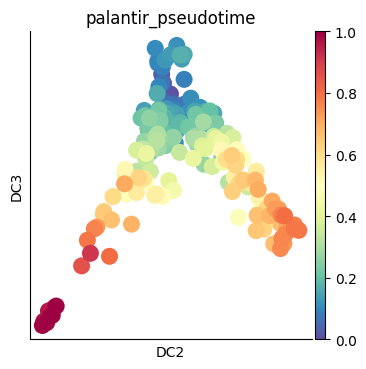

In [72]:
sc.pl.diffmap(meta_adata, color=['palantir_pseudotime'], size=600, legend_fontoutline=3, components=['2,3'])

In [73]:
adata

AnnData object with n_obs × n_vars = 1212830 × 36807
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top

In [74]:
meta_adata

AnnData object with n_obs × n_vars = 204 × 106
    obs: 'Dataset', 'sample_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'condition', 'manner_of_death', 'reference_genome', 'sample_source', 'sampled_site_condition', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'assay', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covariate', 'batch_covar_final', 'institute_meta', 'sample_collection_site', 'manner_of_death_meta', 'sample_source_meta', 'sex_ontology_term_id', 'sample_collection_method_meta', 'sampled_site_condition_meta', 'tissue_ontology_term_id', 'tissue_free_text', 'sample_preservation_method', 'suspension_type_meta', 'cell_enrichment_meta', 'sequenced_fragment', 'sequencing_platform', 'gene_annotation_version_meta', 'alignment_software_meta', 'intron_inclusion', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'Dataset_meta', 'Dataset_source', 'age', '

In [75]:
adata.obs["Dataset_Source"] = adata.obs["Dataset"].astype(str) + "_" + adata.obs["source"].astype(str)
adata.obs["Dataset_source"] = adata.obs["Dataset"].astype(str) + "_" + adata.obs["source"].astype(str)
adata.obs['Dataset_ID'] = adata.obs["Dataset_Source"].astype(str) + ' : ' + adata.obs['donor_id'].astype(str)

In [76]:
meta_adata.obs['Source'] = meta_adata.obs_names.map(dict(zip(adata.obs['Dataset_ID'], adata.obs['source'])))


In [77]:
meta_adata.obs.head()

,Dataset,sample_id,alignment_software,assay_ontology_term_id,institute,library_id,condition,manner_of_death,reference_genome,sample_source,...,age_from_age_binned,age_from_hsapdv_harmonized,age_from_hsapdv_harmonized_binned,age_category,leiden_ft_1.5,leiden_ft_0.5,leiden_ft_0.75,disease_root_ixs_filtered,HbA1c_category,iroot
Dataset_ID,,,,,,,,,,,,,,,,,,,,,
GSE101207_remapped_core : Non_diabetic_donor_6,GSE101207_remapped,SAMN08051215,STAR,EFO:0008722,NaN,SRX3413848,NaN,unknown,GRCh37,organ donor,...,NaN,"(40.0, 50.0)",6.0,Middle-Aged Adult (40–60 years),3,0,0,NaN,normal,77
GSE101207_remapped_core : Diabetic_donor_2,GSE101207_remapped,SAMN07343857,STAR,EFO:0008722,NaN,SRX2996340,NaN,unknown,GRCh37,organ donor,...,NaN,"(60.0, 70.0)",8.0,Older Adult (≥60 years),3,0,0,NaN,normal,77
GSE101207_remapped_core : Diabetic_donor_3,GSE101207_remapped,SAMN08051214,STAR,EFO:0008722,NaN,SRX3413849,NaN,unknown,GRCh37,organ donor,...,NaN,"(50.0, 60.0)",7.0,Middle-Aged Adult (40–60 years),6,0,3,NaN,high,77
GSE101207_remapped_core : Non_diabetic_donor_5,GSE101207_remapped,SAMN07343859,STAR,EFO:0008722,NaN,SRX2996338,NaN,unknown,GRCh37,organ donor,...,NaN,"(20.0, 30.0)",4.0,Young Adult (20–40 years),1,2,3,healthy_1.0,normal,77
GSE101207_remapped_core : Non_diabetic_donor_4,GSE101207_remapped,SAMN07343860,STAR,EFO:0008722,NaN,SRX2996337,NaN,unknown,GRCh37,organ donor,...,NaN,"(50.0, 60.0)",7.0,Middle-Aged Adult (40–60 years),6,0,3,NaN,normal,77


In [78]:
meta_adata.obs.groupby('disease')['palantir_pseudotime'].median()

/tmp/ipykernel_2437355/4144767802.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby('disease')['palantir_pseudotime'].median()


disease
healthy    0.202732
aab        0.648749
T1D        0.671491
T2D        0.601832
Name: palantir_pseudotime, dtype: float64

In [79]:
meta_adata_diabetes = meta_adata[meta_adata.obs.disease.str.contains('T1D|T2D|aab')].copy()
meta_adata_diabetes.obs.disease.value_counts()

disease
T1D    25
aab    21
T2D    18
Name: count, dtype: int64

/tmp/ipykernel_2437355/3728140558.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(meta_adata_diabetes, resolution=1.5, key_added="leiden_ft", neighbors_key="neighbors_sampleclr_ft")


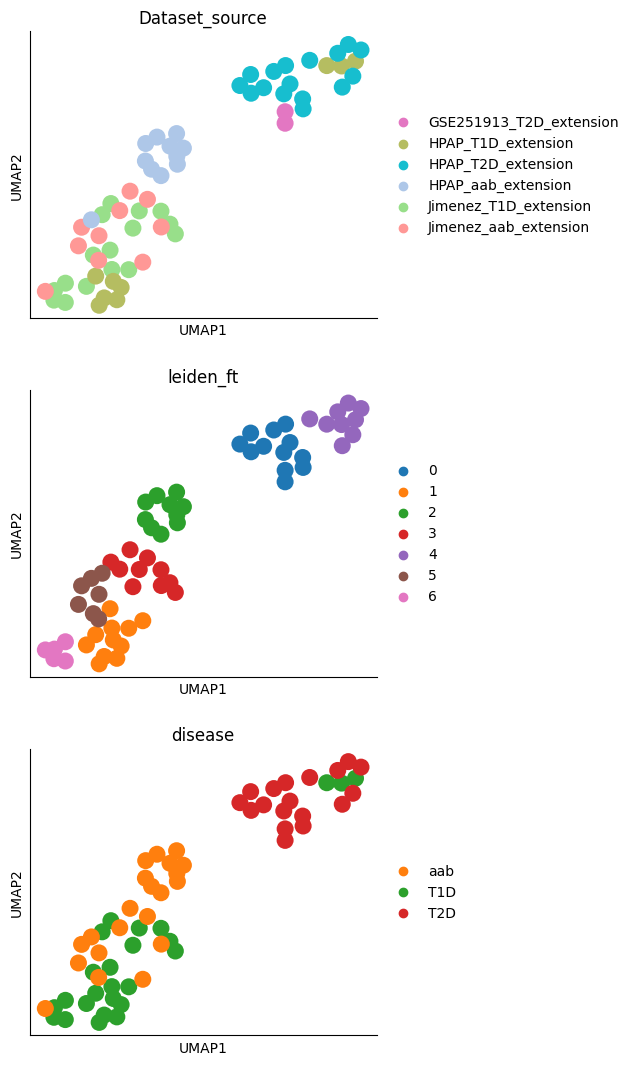

In [80]:
sc.pp.neighbors(meta_adata_diabetes, use_rep="X_sampleclr_ft", key_added="neighbors_sampleclr_ft", n_neighbors=5)
sc.tl.umap(meta_adata_diabetes, neighbors_key="neighbors_sampleclr_ft", min_dist=0.5)
sc.tl.leiden(meta_adata_diabetes, resolution=1.5, key_added="leiden_ft", neighbors_key="neighbors_sampleclr_ft")
sc.pl.umap(meta_adata_diabetes, color=['Dataset_source', 'leiden_ft', 'disease'], size=600,  legend_fontoutline=3, ncols=1)

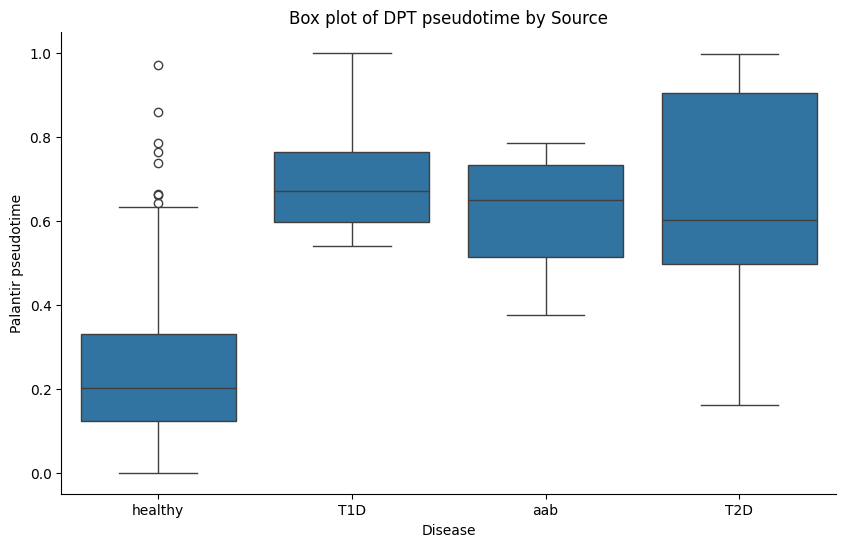

In [81]:

plt.figure(figsize=(10,6))
sns.boxplot(x='disease', y='palantir_pseudotime', data=meta_adata.obs, order=meta_adata.obs['disease'].value_counts().index)
plt.title('Box plot of DPT pseudotime by Source')
plt.xlabel('Disease')
plt.ylabel('Palantir pseudotime')
plt.show()

In [82]:
import pandas as pd
import statsmodels.formula.api as smf
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
obs = meta_adata.obs.copy()

obs["palantir_pseudotime"] = pd.to_numeric(obs["palantir_pseudotime"], errors="coerce")
obs = obs.dropna(subset=["palantir_pseudotime", "disease"]).copy()

obs["disease"] = obs["disease"].astype("category")

# Overall group test
model = smf.ols("palantir_pseudotime ~ C(disease)", data=obs).fit()
anova = sm.stats.anova_lm(model, typ=2)
anova

,sum_sq,df,F,PR(>F)
C(disease),7.154812,3.0,69.50121,7.825149e-31
Residual,6.863009,200.0,NaN,NaN


In [93]:
model = smf.ols(
    "palantir_pseudotime ~ C(age_category) + C(sex_ontology_term_id) + BMI + HbA1c",
    data=obs
).fit()

In [94]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     palantir_pseudotime   R-squared:                       0.072
Model:                             OLS   Adj. R-squared:                 -0.028
Method:                  Least Squares   F-statistic:                    0.7198
Date:                 Sat, 23 May 2026   Prob (F-statistic):              0.656
Time:                         13:44:56   Log-Likelihood:                 15.196
No. Observations:                   73   AIC:                            -14.39
Df Residuals:                       65   BIC:                             3.931
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
======================================================================================================================
                                                         coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                              0.1538      0.181      0.851      0.398      -0.207       0.515
C(age_category)[T.Middle-Aged Adult (40–60 years)]    -0.1677      0.114     -1.469      0.147      -0.396       0.060
C(age_category)[T.Older Adult (≥60 years)]            -0.0439      0.230     -0.191      0.849      -0.503       0.415
C(age_category)[T.Pediatric]                           0.0044      0.117      0.038      0.970      -0.229       0.238
C(age_category)[T.Young Adult (20–40 years)]          -0.0641      0.104     -0.618      0.539      -0.271       0.143
C(sex_ontology_term_id)[T.PATO:0000384]               -0.0109      0.050     -0.217      0.829      -0.112       0.090
BMI                                                    0.0053      0.005      1.055      0.295      -0.005       0.015
HbA1c                                                  0.0143      0.013      1.128      0.264      -0.011       0.040
==============================================================================
Omnibus:                       16.183   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.238
Skew:                           1.039   Prob(JB):                     6.65e-05
Kurtosis:                       4.415   Cond. No.                         310.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

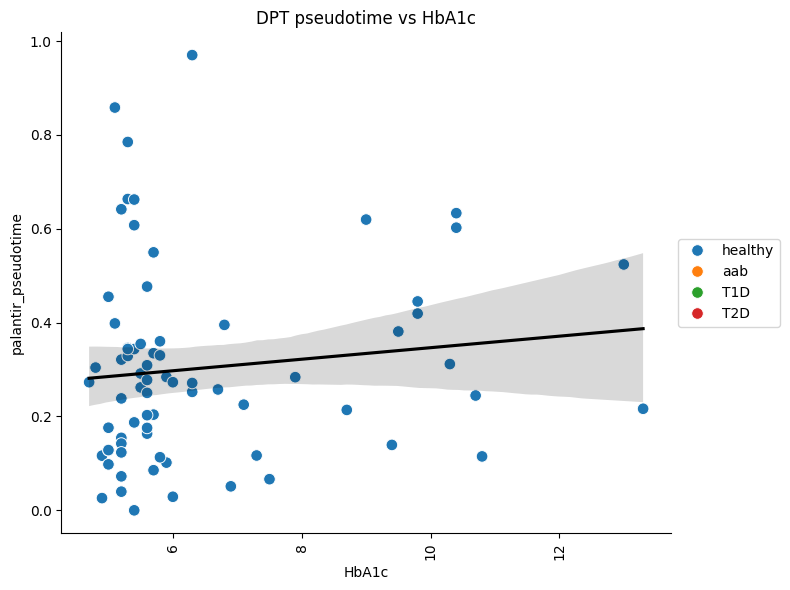

HbA1c Spearman rho: 0.10780421612441524 p: 0.36396726876274876


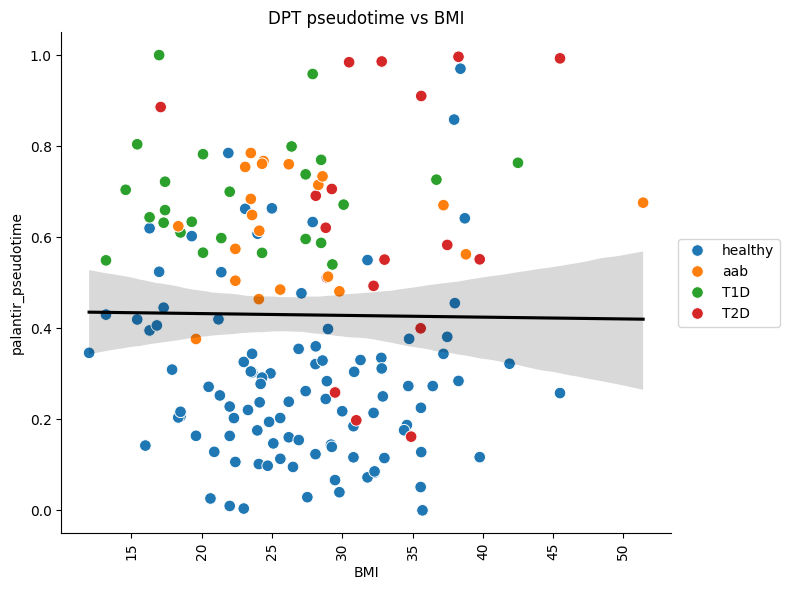

BMI Spearman rho: -0.07202635870169118 p: 0.3593924659586737


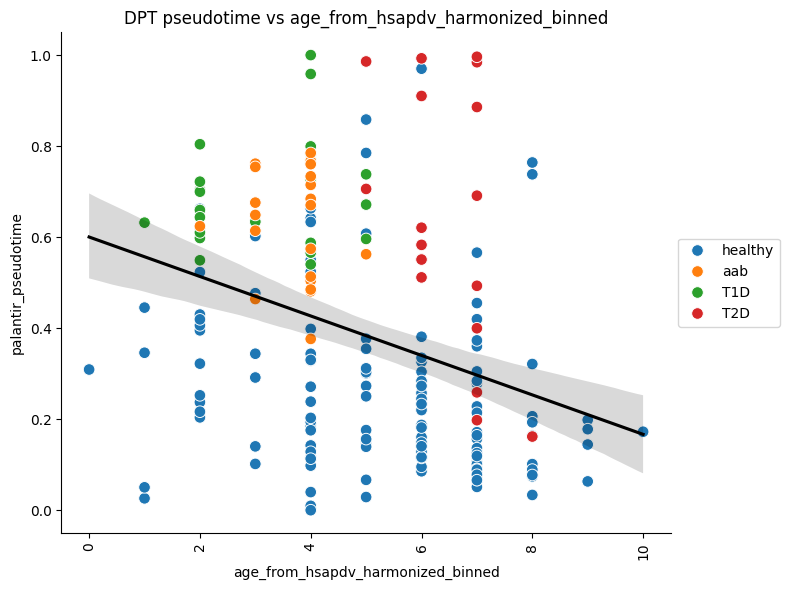

age_from_hsapdv_harmonized_binned Spearman rho: -0.3776507014890368 p: 2.7835421840172658e-08
Skipping regplot for age_category because dtype is not numeric (dtype: object)


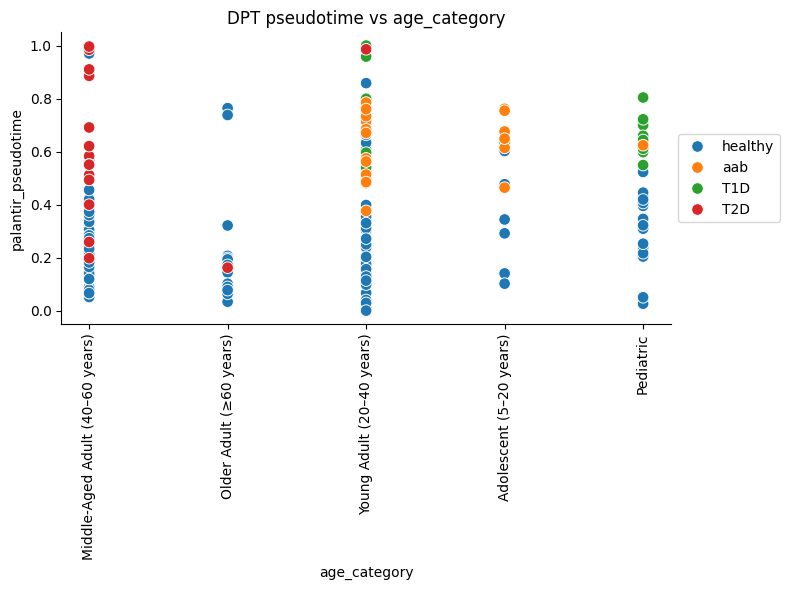

age_category Spearman rho: 0.1893776815899385 p: 0.006808133758994777


In [95]:
clinical_cols = [c for c in ["HbA1c", "BMI", "age_from_hsapdv_harmonized_binned", 'age_category'] if c in obs.columns]

for c in clinical_cols:
    tmp = obs.dropna(subset=[c, "palantir_pseudotime"]).copy()
    col_dtype = tmp[c].dtype

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=tmp, x=c, y="palantir_pseudotime", hue="disease", s=70)
    if np.issubdtype(tmp[c].dtype, np.number):
        sns.regplot(data=tmp, x=c, y="palantir_pseudotime", scatter=False, color="black")
    else:
        print(f"Skipping regplot for {c} because dtype is not numeric (dtype: {col_dtype})")
    plt.title(f"DPT pseudotime vs {c}")
    plt.xticks(rotation=90)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

    r, p = stats.spearmanr(tmp[c], tmp["palantir_pseudotime"])
    print(c, "Spearman rho:", r, "p:", p)

In [98]:
meta_adata.obs.groupby(['HbA1c_category', 'disease']).size().unstack()

/tmp/ipykernel_2437355/2574629583.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby(['HbA1c_category', 'disease']).size().unstack()


disease,healthy,aab,T1D,T2D
HbA1c_category,,,,
high,92,21,25,18
normal,48,0,0,0


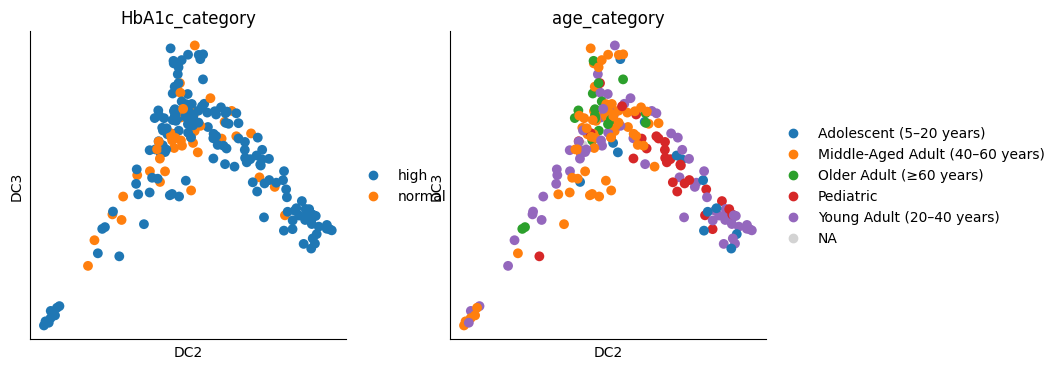

In [99]:
sc.pl.diffmap(meta_adata, color=['HbA1c_category', 'age_category'], components=['2,3'], size=200,)

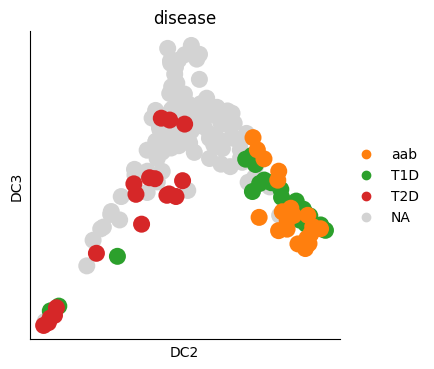

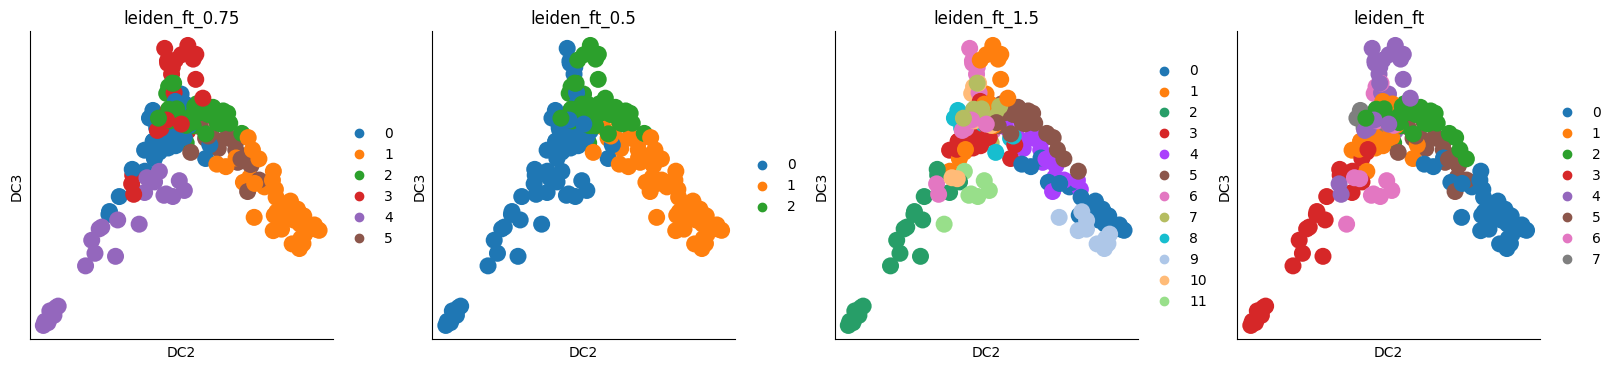

In [100]:
sc.pl.diffmap(meta_adata, color=['disease'], components=['2,3'], size=600, groups=['T1D', 'T2D', 'aab'])
sc.pl.diffmap(meta_adata, color=['leiden_ft_0.75', 'leiden_ft_0.5', 'leiden_ft_1.5', 'leiden_ft'], components=['2,3'], size=600)

In [101]:
sc.tl.rank_genes_groups(meta_adata, 'leiden_ft_0.75', method='wilcoxon')

In [102]:
meta_adata_endocrine = meta_adata[:, meta_adata.var_names[meta_adata.var_names.str.contains(f'Alpha|Beta|Delta|Epsilon|Pancreatic')]].copy()

In [103]:
sc.pp.normalize_total(meta_adata_endocrine, target_sum=100, layer='composition_raw')
sc.pp.log1p(meta_adata_endocrine)
sc.tl.rank_genes_groups(meta_adata_endocrine, 'leiden_ft_0.75', method='wilcoxon', layer='composition_raw')

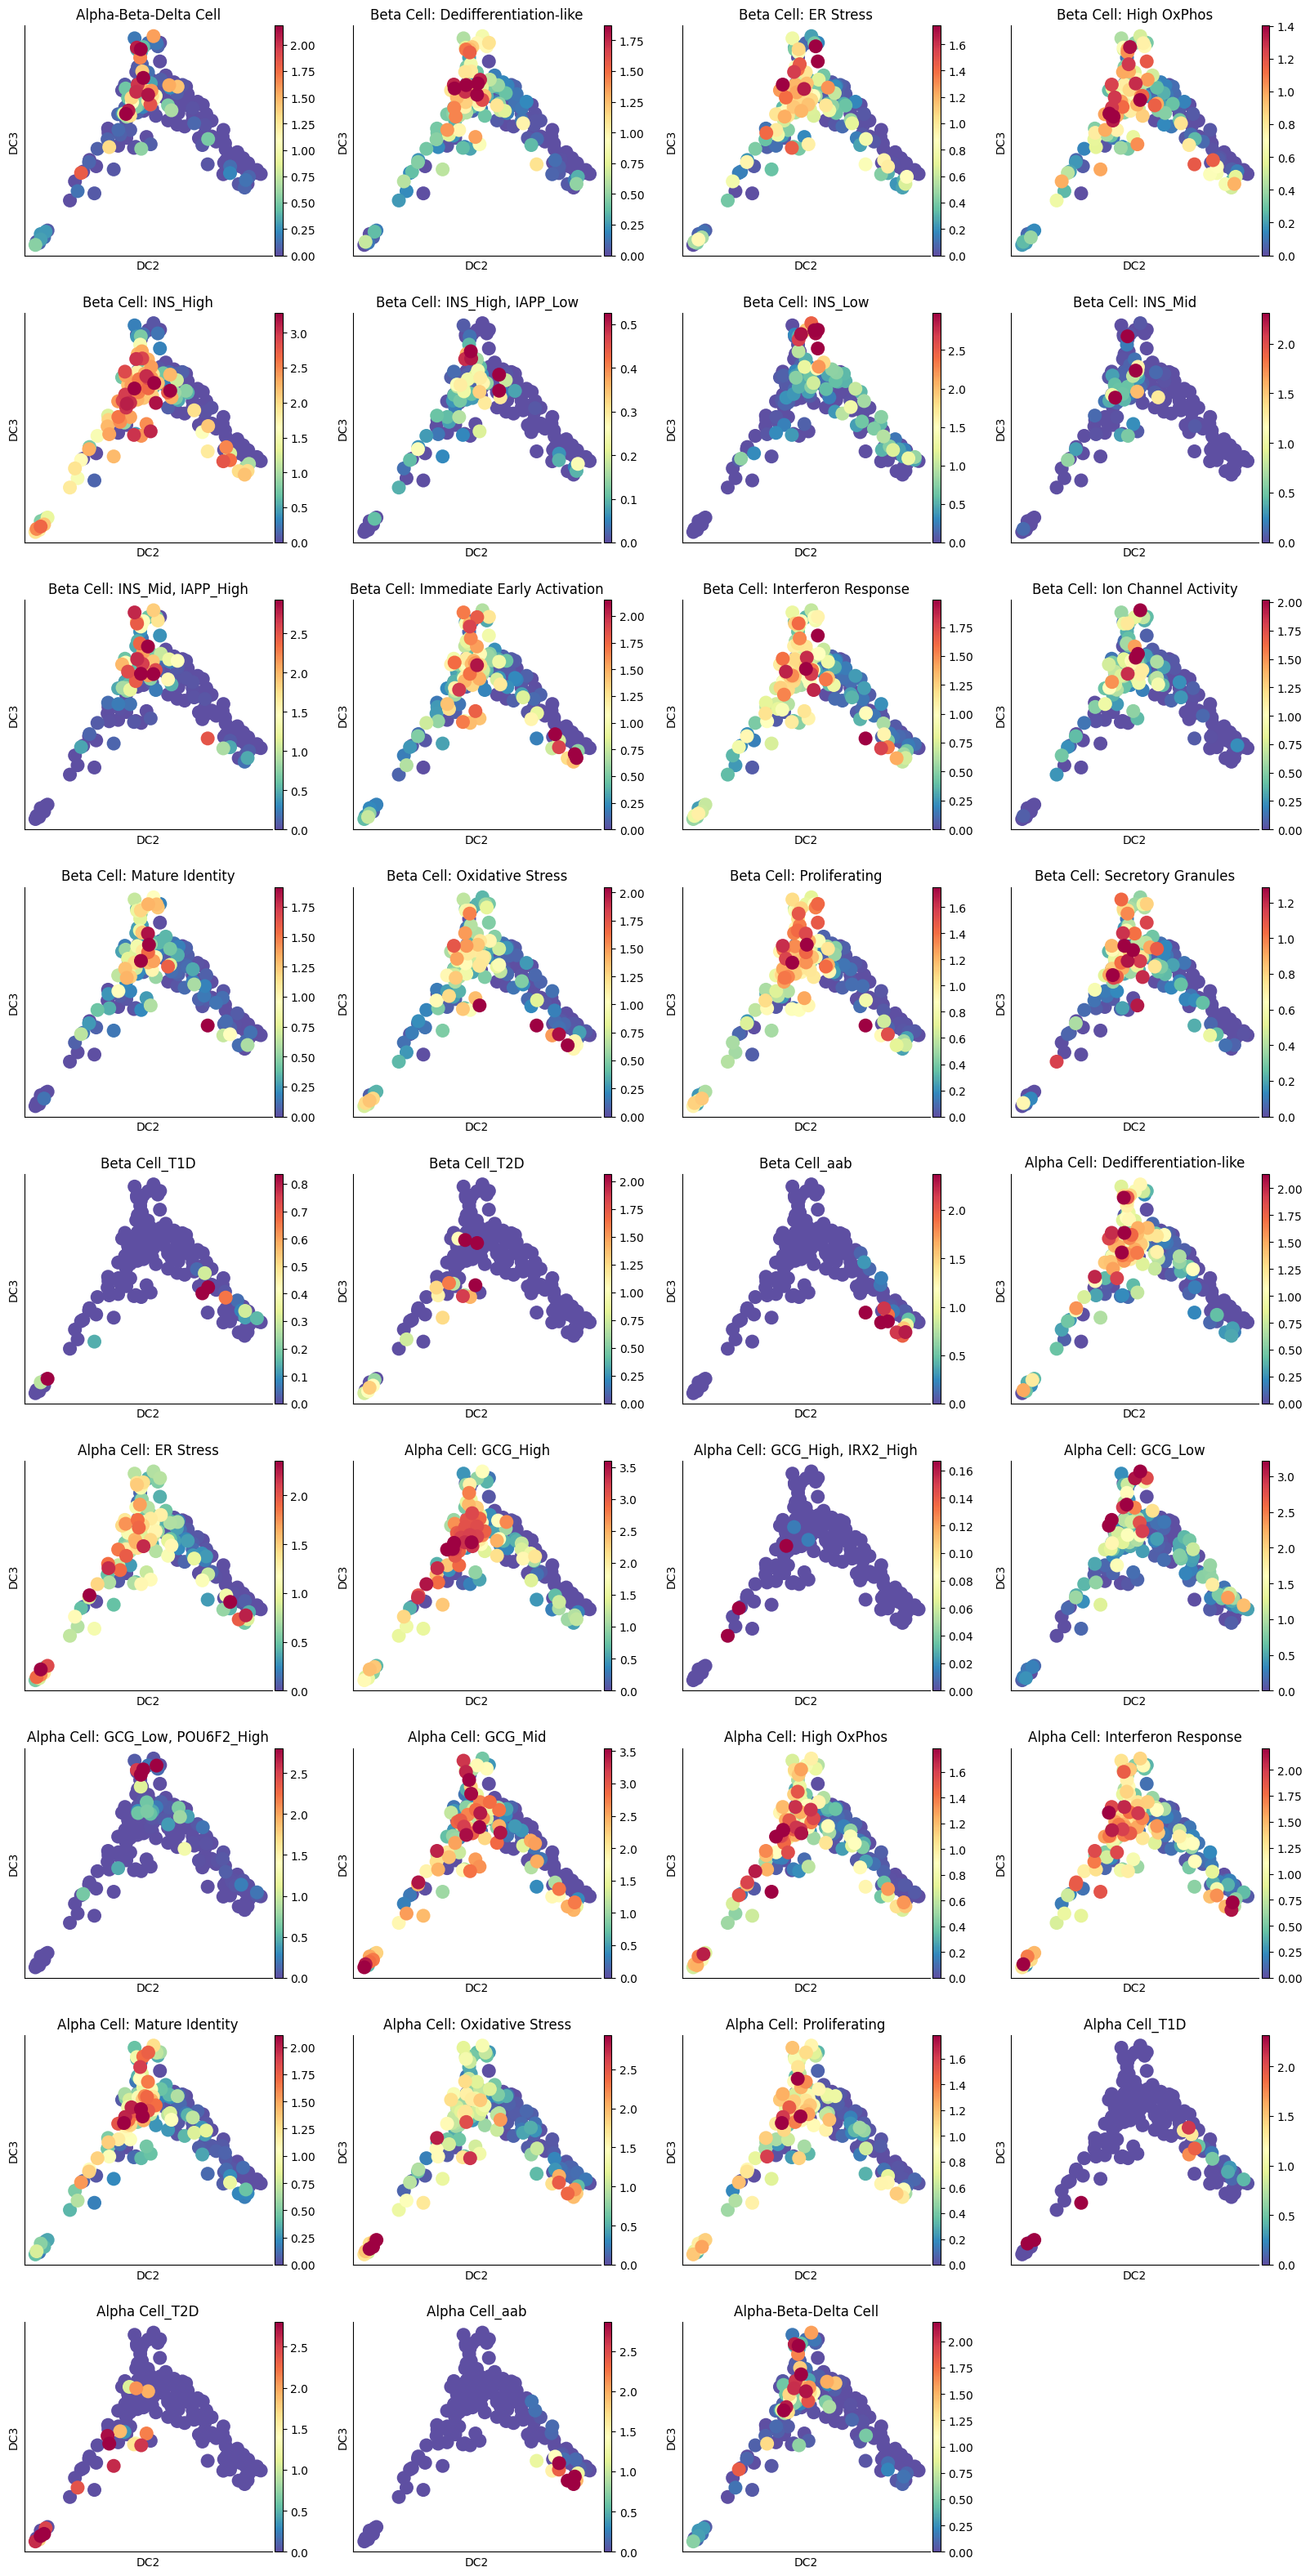

In [104]:
beta_cols = meta_adata.var_names[meta_adata.var_names.str.contains(f'Beta')].tolist()
alpha_cols = meta_adata.var_names[meta_adata.var_names.str.contains(f'Alpha')].tolist()
sc.pl.diffmap(meta_adata_endocrine, color=beta_cols + alpha_cols, components=['2,3'], size=600, vmax='p99', vmin='p1')

In [105]:
pd.DataFrame(meta_adata_endocrine.uns['rank_genes_groups']['names']).head(7)

,0,1,2,3,4,5
0,Alpha Cell: GCG_High,Beta Cell_aab,Delta Cell,"Beta Cell: INS_Mid, IAPP_High",Alpha Cell: Oxidative Stress,Alpha Cell: GCG_High
1,Beta Cell: INS_Mid,Alpha Cell_aab,Delta Cell: Dedifferentiation-like,Alpha-Beta-Delta Cell,Alpha Cell_T2D,Epsilon Cell
2,Alpha Cell: Mature Identity,Alpha Cell: GCG_Low,Delta Cell: ER Stress,Delta Cell: Dedifferentiation-like,Beta Cell_T2D,Alpha Cell: GCG_Mid
3,Alpha Cell: Dedifferentiation-like,Delta Cell_aab,Beta Cell: Dedifferentiation-like,Beta Cell: Dedifferentiation-like,Pancreatic Polypeptide Cell_T2D,Alpha Cell: High OxPhos
4,Beta Cell: INS_High,Alpha Cell: Oxidative Stress,Beta Cell: INS_Low,Delta Cell: Proliferating,Beta Cell: Oxidative Stress,Beta Cell: INS_High
5,Alpha Cell: Proliferating,Alpha Cell_T1D,Delta Cell: High OxPhos,Pancreatic Polypeptide Cell: Interferon Response,Alpha Cell: ER Stress,Alpha Cell: ER Stress
6,Beta Cell: Proliferating,Beta Cell: INS_Low,Beta Cell: ER Stress,Alpha Cell: Dedifferentiation-like,Delta Cell_T2D,Pancreatic Polypeptide Cell


In [106]:
import anndata as ad
from scipy import sparse

def to_dense(X):
    return X.toarray() if sparse.issparse(X) else np.asarray(X)

def make_pseudobulk(
    adata_in,
    cell_mask,
    patient_col="Dataset_ID",
    meta_cols=("Dataset", "suspension_type", "Source"),
    count_layer="counts",
    min_cells=0,
    target_sum=1e6,
):
    a = adata_in[cell_mask].copy()
    cell_counts = a.obs[patient_col].value_counts()
    keep_patients = cell_counts[cell_counts >= min_cells].index
    a = a[a.obs[patient_col].isin(keep_patients)].copy()

    X = a.layers[count_layer] if count_layer in a.layers else a.X
    X = to_dense(X)

    df = pd.DataFrame(X, index=a.obs_names, columns=a.var_names)
    df[patient_col] = a.obs[patient_col].values

    pb = df.groupby(patient_col).sum()

    pb_adata = ad.AnnData(
        X=pb.values.astype(np.float32),
        obs=pd.DataFrame(index=pb.index),
        var=pd.DataFrame(index=pb.columns),
    )

    meta_cols_present = [c for c in meta_cols if c in a.obs.columns]
    patient_meta = (
        a.obs[[patient_col] + meta_cols_present]
        .drop_duplicates(subset=patient_col)
        .set_index(patient_col))
    pb_adata.obs = pb_adata.obs.join(patient_meta, how="left")
    pb_adata.obs["n_cells_lineage"] = cell_counts.reindex(pb_adata.obs_names).astype(int).values

    pb_adata.layers["counts"] = pb_adata.X.copy()

    sc.pp.normalize_total(pb_adata, target_sum=target_sum)
    sc.pp.log1p(pb_adata)

    return pb_adata

In [107]:
adata.obs['Level_4_extension_diabetes_simplified'] = adata.obs.Level_4_extension_diabetes.copy()
adata.obs.Level_4_extension_diabetes_simplified = np.where(adata.obs.Level_3_extension_diabetes.str.contains('T1D|T2D|aab'), adata.obs.Level_3_extension_diabetes, adata.obs.Level_4_extension_diabetes)

In [108]:
beta_mask = adata.obs.Level_4_extension_diabetes_simplified.str.contains('Beta')
beta_pb = make_pseudobulk(
    adata,
    beta_mask,
    patient_col="Dataset_ID",
    meta_cols=("Dataset_Source", "suspension_type", "source"),
    count_layer="counts",
)

In [109]:
alpha_mask = adata.obs.Level_4_extension_diabetes_simplified.str.contains('Alpha')
alpha_pb = make_pseudobulk(
    adata,
    alpha_mask,
    patient_col="Dataset_ID",
    meta_cols=("Dataset_Source", "suspension_type", "source"),
    count_layer="counts",
)

In [110]:
beta_pb

AnnData object with n_obs × n_vars = 210 × 36807
    obs: 'Dataset_Source', 'suspension_type', 'source', 'n_cells_lineage'
    uns: 'log1p'
    layers: 'counts'

In [111]:
alpha_pb

AnnData object with n_obs × n_vars = 219 × 36807
    obs: 'Dataset_Source', 'suspension_type', 'source', 'n_cells_lineage'
    uns: 'log1p'
    layers: 'counts'

In [112]:
meta_adata.obs

,Dataset,sample_id,alignment_software,assay_ontology_term_id,institute,library_id,condition,manner_of_death,reference_genome,sample_source,...,age_from_age_binned,age_from_hsapdv_harmonized,age_from_hsapdv_harmonized_binned,age_category,leiden_ft_1.5,leiden_ft_0.5,leiden_ft_0.75,disease_root_ixs_filtered,HbA1c_category,iroot
Dataset_ID,,,,,,,,,,,,,,,,,,,,,
GSE101207_remapped_core : Non_diabetic_donor_6,GSE101207_remapped,SAMN08051215,STAR,EFO:0008722,NaN,SRX3413848,NaN,unknown,GRCh37,organ donor,...,NaN,"(40.0, 50.0)",6.0,Middle-Aged Adult (40–60 years),3,0,0,NaN,normal,77
GSE101207_remapped_core : Diabetic_donor_2,GSE101207_remapped,SAMN07343857,STAR,EFO:0008722,NaN,SRX2996340,NaN,unknown,GRCh37,organ donor,...,NaN,"(60.0, 70.0)",8.0,Older Adult (≥60 years),3,0,0,NaN,normal,77
GSE101207_remapped_core : Diabetic_donor_3,GSE101207_remapped,SAMN08051214,STAR,EFO:0008722,NaN,SRX3413849,NaN,unknown,GRCh37,organ donor,...,NaN,"(50.0, 60.0)",7.0,Middle-Aged Adult (40–60 years),6,0,3,NaN,high,77
GSE101207_remapped_core : Non_diabetic_donor_5,GSE101207_remapped,SAMN07343859,STAR,EFO:0008722,NaN,SRX2996338,NaN,unknown,GRCh37,organ donor,...,NaN,"(20.0, 30.0)",4.0,Young Adult (20–40 years),1,2,3,healthy_1.0,normal,77
GSE101207_remapped_core : Non_diabetic_donor_4,GSE101207_remapped,SAMN07343860,STAR,EFO:0008722,NaN,SRX2996337,NaN,unknown,GRCh37,organ donor,...,NaN,"(50.0, 60.0)",7.0,Middle-Aged Adult (40–60 years),6,0,3,NaN,normal,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HPAP_aab_extension : HPAP-049,HPAP,HPAP-049,NaN,NaN,missing,NaN,AAB,NaN,NaN,NaN,...,"(20.0, 30.0)","(20.0, 30.0)",4.0,Young Adult (20–40 years),9,1,1,aab,high,77
HPAP_aab_extension : HPAP-050,HPAP,HPAP-050,NaN,NaN,missing,NaN,AAB,NaN,NaN,NaN,...,"(20.0, 30.0)","(20.0, 30.0)",4.0,Young Adult (20–40 years),9,1,1,aab,high,77
HPAP_aab_extension : HPAP-072,HPAP,HPAP-072,NaN,NaN,missing,NaN,AAB,NaN,NaN,NaN,...,"(15.0, 20.0)","(15.0, 20.0)",3.0,Adolescent (5–20 years),9,1,1,aab,high,77


In [113]:
X_beta = beta_pb.X.toarray() if not isinstance(beta_pb.X, np.ndarray) else beta_pb.X
X_alpha = alpha_pb.X.toarray() if not isinstance(alpha_pb.X, np.ndarray) else alpha_pb.X
beta_pb.obs = beta_pb.obs.join(
    meta_adata.obs[[
        "palantir_pseudotime",
        "age_category",
        "sex_ontology_term_id",
        "HbA1c", "disease"
    ]],
    on="Dataset_ID"
    
)
alpha_pb.obs = alpha_pb.obs.join(
    meta_adata.obs[[
        "palantir_pseudotime",
        "age_category",
        "sex_ontology_term_id",
        "HbA1c", "disease"
    ]],
    on="Dataset_ID"
)

In [114]:
print(len(alpha_pb.var_names[alpha_pb.var_names.str.startswith(("MT", "RPL", "RPS", "HB"))
    | alpha_pb.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")]))
alpha_pb.var_names[alpha_pb.var_names.str.startswith(("MT", "RPL", "RPS", "HB"))|alpha_pb.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")]

11219


Index(['AB015752.1', 'AC000032.1', 'AC000036.1', 'AC000050.1', 'AC000058.1',
       'AC000061.1', 'AC000065.1', 'AC000065.2', 'AC000067.1', 'AC000068.1',
       ...
       'RPS6KA6', 'RPS6KB1', 'RPS6KB2', 'RPS6KB2-AS1', 'RPS6KC1', 'RPS6KL1',
       'RPS7', 'RPS8', 'RPS9', 'RPSA'],
      dtype='object', length=11219)

In [115]:
import re
print(f'Genes before filtering: {len(beta_pb.var_names)}')
sc.pp.filter_genes(beta_pb, min_cells=5)
bad = (
    beta_pb.var_names.str.startswith(("MT", "RPL", "RPS", "HB"))
    | beta_pb.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")
)
beta_pb = beta_pb[:, ~bad].copy()
print(f'Genes after filtering: {len(beta_pb.var_names)}')

print(f'Genes before filtering: {len(alpha_pb.var_names)}')
sc.pp.filter_genes(alpha_pb, min_cells=5)
bad = (
    alpha_pb.var_names.str.startswith(("MT", "RPL", "RPS", "HB"))
    | alpha_pb.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")
)
alpha_pb = alpha_pb[:, ~bad].copy()
print(f'Genes after filtering: {len(alpha_pb.var_names)}')

Genes before filtering: 36807
Genes after filtering: 22559
Genes before filtering: 36807
Genes after filtering: 22508


In [116]:
len(alpha_pb.var_names[alpha_pb.var_names.str.startswith(("MT", "RPL", "RPS", "HB"))
    | alpha_pb.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")])

0

In [117]:
print(beta_pb.shape)
print(alpha_pb.shape)

(210, 22559)
(219, 22508)


In [118]:
beta_pb.obs["palantir_pseudotime"] = pd.to_numeric(beta_pb.obs["palantir_pseudotime"], errors="coerce")
beta_pb.obs["HbA1c"] = pd.to_numeric(beta_pb.obs["HbA1c"], errors="coerce")
alpha_pb.obs["palantir_pseudotime"] = pd.to_numeric(alpha_pb.obs["palantir_pseudotime"], errors="coerce")
alpha_pb.obs["HbA1c"] = pd.to_numeric(alpha_pb.obs["HbA1c"], errors="coerce")


In [119]:
beta_pb

AnnData object with n_obs × n_vars = 210 × 22559
    obs: 'Dataset_Source', 'suspension_type', 'source', 'n_cells_lineage', 'palantir_pseudotime', 'age_category', 'sex_ontology_term_id', 'HbA1c', 'disease'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [120]:
beta_pb = beta_pb[beta_pb.obs_names.isin(meta_adata.obs_names.tolist())].copy()
alpha_pb = alpha_pb[alpha_pb.obs_names.isin(meta_adata.obs_names.tolist())].copy()

In [121]:
beta_pb.obs[["palantir_pseudotime", "age_category", "sex_ontology_term_id", "HbA1c"]].isna().sum()

palantir_pseudotime       0
age_category              1
sex_ontology_term_id     57
HbA1c                   124
dtype: int64

In [122]:
import warnings
warnings.filterwarnings("ignore")

In [123]:
beta_pb.obs.source.value_counts()

source
core             139
aab_extension     21
T2D_extension     18
T1D_extension     18
Name: count, dtype: int64

In [124]:
alpha_pb.obs.source.value_counts()

source
core             140
T1D_extension     25
aab_extension     21
T2D_extension     18
Name: count, dtype: int64

In [125]:
beta_pb.write('beta_pb.h5ad')
alpha_pb.write('alpha_pb.h5ad')

In [126]:
from scipy import sparse
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm

def palantir_gene_test(
    pb_adata,
    time_col="palantir_pseudotime",
    covariates=("age_category", "suspension_type")):
    X_expr = pb_adata.X
    if sparse.issparse(X_expr):
        X_expr = X_expr.toarray()
    else:
        X_expr = np.asarray(X_expr)

    obs = pb_adata.obs.copy()
    obs[time_col] = pd.to_numeric(obs[time_col], errors="coerce")

    usable_covs = [c for c in covariates if c in obs.columns]

    meta = obs[[time_col] + usable_covs].copy()

    design = pd.DataFrame(index=meta.index)
    design[time_col] = meta[time_col].astype(float)

    for cov in usable_covs:
        if meta[cov].dtype.name in ["category", "object"]:
            dummies = pd.get_dummies(meta[cov], prefix=cov, drop_first=True)
            design = pd.concat([design, dummies], axis=1)
        else:
            design[cov] = pd.to_numeric(meta[cov], errors="coerce")

    results = []

    for j, gene in tqdm(list(enumerate(pb_adata.var_names)), desc="Palantir gene models"):
        y = X_expr[:, j].astype(float)

        df = design.copy()
        df["expr"] = y
        df = df.dropna()

        try:
            y_fit = df["expr"].values
            X_fit = df.drop(columns=["expr"])
            X_fit = sm.add_constant(X_fit).astype(float)

            fit = sm.OLS(y_fit, X_fit).fit()

            coef = fit.params[time_col]
            pval = fit.pvalues[time_col]
            r2 = fit.rsquared

            results.append((gene, coef, pval, df.shape[0], r2))

        except Exception:
            results.append((gene, np.nan, np.nan, df.shape[0], np.nan))

    res = pd.DataFrame(
        results,
        columns=["gene", "palantir_coef", "palantir_pval", "n", "r2"]
    )

    res["palantir_padj"] = multipletests(
        res["palantir_pval"].fillna(1.0),
        method="fdr_bh"
    )[1]

    res = res.sort_values("palantir_padj", na_position="last")
    return res

In [127]:
beta_palantir = palantir_gene_test(
    beta_pb,
)

alpha_palantir = palantir_gene_test(
    alpha_pb,
)

Palantir gene models:   2%|▏         | 370/22559 [00:01<01:00, 367.04it/s]

Palantir gene models: 100%|██████████| 22508/22508 [01:00<00:00, 373.75it/s]


In [128]:
beta_palantir.head()

,gene,palantir_coef,palantir_pval,n,r2,palantir_padj
10338,LINC01578,5.170547,6.584841e-23,196,0.485967,7.427372e-19
7573,H2AFY,5.344753,4.589884e-23,196,0.481910,7.427372e-19
6106,FAM92A,4.613708,3.190186e-22,196,0.470351,2.398914e-18
5845,FAM102A,4.849521,6.877345e-22,196,0.465732,3.878651e-18
6794,GARS,4.162892,1.908358e-21,196,0.460104,7.175107e-18


In [129]:
alpha_palantir.head()

,gene,palantir_coef,palantir_pval,n,r2,palantir_padj
10310,LINC01578,5.525558,3.826252e-26,204,0.516117,4.306064e-22
6038,FAM49B,5.479584,3.730442e-26,204,0.523542,4.306064e-22
7562,H2AFY,5.832419,8.979816e-26,204,0.505941,6.737256e-22
2527,CASC4,5.835986,1.756644e-25,204,0.512157,7.907707e-22
2598,CBWD1,4.483537,1.691695e-25,204,0.501529,7.907707e-22


In [130]:
def branch_palantir_gene_test(
    pb_adata,
    branch_sources,
    time_col="palantir_pseudotime",
    disease_col="disease",
    covariates=("age_category", "suspension_type"),
):
    pb = pb_adata[pb_adata.obs[disease_col].isin(branch_sources)].copy()

    X = pb.X.toarray() if sparse.issparse(pb.X) else np.asarray(pb.X)
    obs = pb.obs.copy()
    obs[time_col] = pd.to_numeric(obs[time_col], errors="coerce")

    usable_covs = [c for c in covariates if c in obs.columns]

    design = pd.DataFrame(index=obs.index)
    design[time_col] = obs[time_col].astype(float)

    for cov in usable_covs:
        if obs[cov].dtype.name in ["category", "object"]:
            dummies = pd.get_dummies(obs[cov], prefix=cov, drop_first=True)
            design = pd.concat([design, dummies], axis=1)
        else:
            design[cov] = pd.to_numeric(obs[cov], errors="coerce")

    results = []

    for j, gene in tqdm(list(enumerate(pb.var_names)), desc=f"Branch model {branch_sources}"):
        df = design.copy()
        df["expr"] = X[:, j].astype(float)
        df = df.dropna()

        try:
            y = df["expr"].values
            X_design = df.drop(columns=["expr"])
            X_design = sm.add_constant(X_design).astype(float)

            fit = sm.OLS(y, X_design).fit()

            coef = fit.params[time_col]
            pval = fit.pvalues[time_col]
            r2 = fit.rsquared

            results.append((gene, coef, pval, df.shape[0], r2))

        except Exception:
            results.append((gene, np.nan, np.nan, df.shape[0], np.nan))

    res = pd.DataFrame(
        results,
        columns=["gene", "coef", "pval", "n", "r2"]
    )

    res["padj"] = multipletests(res["pval"].fillna(1.0), method="fdr_bh")[1]
    res["score"] = -np.log10(res["padj"].clip(lower=1e-300)) * res["coef"]

    return res.sort_values("padj", na_position="last")

In [131]:
beta_pb.obs.disease.value_counts()

disease
healthy    139
aab         21
T1D         18
T2D         18
Name: count, dtype: int64

In [132]:
autoimmune_sources = ["healthy", "aab", "T1D"]
beta_autoimmune_palantir = branch_palantir_gene_test(
    beta_pb,
    branch_sources=autoimmune_sources,
    covariates=("age_category", "suspension_type"),
)
alpha_autoimmune_palantir = branch_palantir_gene_test(
    alpha_pb,
    branch_sources=autoimmune_sources,
    covariates=("age_category", "suspension_type"),
)

Branch model ['healthy', 'aab', 'T1D']: 100%|██████████| 22508/22508 [00:59<00:00, 376.53it/s]


In [133]:
t2d_sources = ["healthy", "T2D"]

beta_t2d_palantir = branch_palantir_gene_test(
    beta_pb,
    branch_sources=t2d_sources,
    covariates=("age_category", "suspension_type"),
)

alpha_t2d_palantir = branch_palantir_gene_test(
    alpha_pb,
    branch_sources=t2d_sources,
    covariates=("age_category", "suspension_type"),
)

Branch model ['healthy', 'T2D']: 100%|██████████| 22508/22508 [00:59<00:00, 376.48it/s]


In [134]:
beta_t2d_palantir.head()

,gene,coef,pval,n,r2,padj,score
10261,LINC01481,1.360203,5.403421e-18,157,0.456799,1.218958e-13,17.565683
9842,LINC00653,2.071113,5.886628e-17,157,0.445946,6.639822e-13,25.221691
7835,HIST1H2BC,2.546149,1.380537e-16,157,0.437654,1.038118e-12,30.512423
14869,PIK3IP1-AS1,0.590236,3.994094e-16,157,0.412156,2.252569e-12,6.874672
2316,C9orf116,1.923328,8.740626e-16,157,0.416540,2.972786e-12,22.169889


In [135]:
def get_branch_genes(res, direction="up", padj_thresh=0.05, coef_thresh=0.25, n=100):
    x = res.copy()
    x = x[x["padj"] < padj_thresh]

    if direction == "up":
        x = x[x["coef"] > coef_thresh]
        x = x.sort_values(["score", "coef"], ascending=[False, False])
    elif direction == "down":
        x = x[x["coef"] < -coef_thresh]
        x = x.sort_values(["score", "coef"], ascending=[True, True])
    else:
        raise ValueError("direction must be 'up' or 'down'")

    return x.head(n)

In [136]:
beta_autoimmune_up = get_branch_genes(beta_autoimmune_palantir, "up")
beta_autoimmune_down = get_branch_genes(beta_autoimmune_palantir, "down")

beta_t2d_up = get_branch_genes(beta_t2d_palantir, "up")
beta_t2d_down = get_branch_genes(beta_t2d_palantir, "down")

alpha_autoimmune_up = get_branch_genes(alpha_autoimmune_palantir, "up")
alpha_autoimmune_down = get_branch_genes(alpha_autoimmune_palantir, "down")

alpha_t2d_up = get_branch_genes(alpha_t2d_palantir, "up")
alpha_t2d_down = get_branch_genes(alpha_t2d_palantir, "down")

In [137]:
beta_shared_up = set(beta_autoimmune_up["gene"]) & set(beta_t2d_up["gene"])
beta_autoimmune_specific_up = set(beta_autoimmune_up["gene"]) - set(beta_t2d_up["gene"])
beta_t2d_specific_up = set(beta_t2d_up["gene"]) - set(beta_autoimmune_up["gene"])

beta_shared_down = set(beta_autoimmune_down["gene"]) & set(beta_t2d_down["gene"])
beta_autoimmune_specific_down = set(beta_autoimmune_down["gene"]) - set(beta_t2d_down["gene"])
beta_t2d_specific_down = set(beta_t2d_down["gene"]) - set(beta_autoimmune_down["gene"])

In [138]:
df_summary =pd.DataFrame.from_dict({
    "beta_autoimmune_up": beta_autoimmune_up.gene.tolist(),
    "beta_autoimmune_down": beta_autoimmune_down.gene.tolist(),
    "beta_t2d_up": beta_t2d_up.gene.tolist(),
    "beta_t2d_down": beta_t2d_down.gene.tolist(),
    "alpha_autoimmune_up": alpha_autoimmune_up.gene.tolist(),
    "alpha_autoimmune_down": alpha_autoimmune_down.gene.tolist(),
    "alpha_t2d_up": alpha_t2d_up.gene.tolist(),
    "alpha_t2d_down": alpha_t2d_down.gene.tolist(),
}, orient="index").T

In [139]:
pd.set_option('display.max_rows', None)

In [140]:
df_summary.head(30)

,beta_autoimmune_up,beta_autoimmune_down,beta_t2d_up,beta_t2d_down,alpha_autoimmune_up,alpha_autoimmune_down,alpha_t2d_up,alpha_t2d_down
0,KIAA1324,IAPP,H1FX,SKAP2,KIAA1324,INS,H3F3A,IAPP
1,CASC4,RBP4,H3F3A,IAPP,CASC4,IAPP,H3F3B,ROBO2
2,MPP6,INS,HIST1H1C,G6PC2,KIAA2026,TMSB4X,H1FX,SLC30A8
3,H2AFY,TTR,ATP5MD,SLC30A8,FAM49B,PFN1,ATP5MD,STMN2
4,PRPF4B,FTL,H3F3B,CNTN4,MARCH7,COA3,SARS,CDH18
5,IARS,FTH1,C4orf48,ROBO2,MARCH6,UBB,H2AFJ,CALD1
6,LINC01578,TPI1,ATP5MPL,LYRM7,H2AFY,SERF2,ATP5MPL,G6PC2
7,EPRS,MAFB,H2AFZ,INPP4B,TTC37,FTL,HIST1H1C,CASR
8,MARCH6,PPY,H2AFJ,MYO1E,WDR60,FAU,C4orf48,VAV3
9,FAM49B,OAZ1,LINC01578,SLC4A10,MARCH8,S100A11,LINC01578,CNTN4


In [141]:
df_summary.to_csv('alphabeta_disease_up_down_genes_diabetes.csv')
df_summary.head(20)

,beta_autoimmune_up,beta_autoimmune_down,beta_t2d_up,beta_t2d_down,alpha_autoimmune_up,alpha_autoimmune_down,alpha_t2d_up,alpha_t2d_down
0,KIAA1324,IAPP,H1FX,SKAP2,KIAA1324,INS,H3F3A,IAPP
1,CASC4,RBP4,H3F3A,IAPP,CASC4,IAPP,H3F3B,ROBO2
2,MPP6,INS,HIST1H1C,G6PC2,KIAA2026,TMSB4X,H1FX,SLC30A8
3,H2AFY,TTR,ATP5MD,SLC30A8,FAM49B,PFN1,ATP5MD,STMN2
4,PRPF4B,FTL,H3F3B,CNTN4,MARCH7,COA3,SARS,CDH18
5,IARS,FTH1,C4orf48,ROBO2,MARCH6,UBB,H2AFJ,CALD1
6,LINC01578,TPI1,ATP5MPL,LYRM7,H2AFY,SERF2,ATP5MPL,G6PC2
7,EPRS,MAFB,H2AFZ,INPP4B,TTC37,FTL,HIST1H1C,CASR
8,MARCH6,PPY,H2AFJ,MYO1E,WDR60,FAU,C4orf48,VAV3
9,FAM49B,OAZ1,LINC01578,SLC4A10,MARCH8,S100A11,LINC01578,CNTN4


In [142]:
df_shared_specific = pd.DataFrame.from_dict({
    "beta_shared_up": beta_shared_up,
    "beta_autoimmune_specific_up": beta_autoimmune_specific_up,
    "beta_t2d_specific_up": beta_t2d_specific_up,
    "beta_shared_down": beta_shared_down,
    "beta_autoimmune_specific_down": beta_autoimmune_specific_down,
    "beta_t2d_specific_down": beta_t2d_specific_down}, orient="index").T
df_shared_specific.to_csv('alphabeta_shared_specific_genes_diabetes.csv')

In [143]:
df_shared_specific.head(30)

,beta_shared_up,beta_autoimmune_specific_up,beta_t2d_specific_up,beta_shared_down,beta_autoimmune_specific_down,beta_t2d_specific_down
0,CBWD5,GARS-DT,PAXIP1-AS1,DHRS2,TMEM258,ROBO2
1,MARCH9,FAM155A,RPARP-AS1,ID1,S100A11,DPP6
2,ATP5MPL,MPP5,LINC00653,IAPP,SF3B5,CCDC91
3,TCTEX1D2,CCDC130,H2AFJ,MAFB,CSTB,NBEA
4,TARSL2,FAM160B2,YTHDF3-AS1,TMEM17,STMN1,CMC1
5,CCDC84,WDYHV1,C6orf226,None,PCSK1N,STK3
6,C3orf14,LINC01004,KARS,None,FKBP4,PTGR1
7,LINC00476,RARS,CCDC96,None,FTL,INPP4B
8,GARS,CASTOR3,H1FX,None,CLU,SOX5
9,FAM102A,FAM160B1,C4orf48,None,SERF2,CTNNA2


In [144]:
meta_adata[meta_adata.obs['root_ixs'] == 1.0].obs

,Dataset,sample_id,alignment_software,assay_ontology_term_id,institute,library_id,condition,manner_of_death,reference_genome,sample_source,...,age_from_age_binned,age_from_hsapdv_harmonized,age_from_hsapdv_harmonized_binned,age_category,leiden_ft_1.5,leiden_ft_0.5,leiden_ft_0.75,disease_root_ixs_filtered,HbA1c_category,iroot
Dataset_ID,,,,,,,,,,,,,,,,,,,,,
HPAP_core : HPAP-080,HPAP,Control_ 24,Cellranger v6.1,EFO:0009922,NaN,Control_ 24_CS,NaN,unknown,GRCh38,organ donor,...,NaN,"(20.0, 30.0)",4.0,Young Adult (20–40 years),6,0,3,NaN,normal,77


In [145]:
adata[adata.obs.Level_4_extension.str.contains('Alpha|Beta|Delta|Epsilon|Pancreatic')].obs.Level_4_extension_diabetes_simplified.value_counts()

Level_4_extension_diabetes_simplified
Alpha Cell: GCG_High                                43934
Beta Cell: INS_High                                 31292
Alpha Cell: GCG_Mid                                 30342
Alpha Cell: GCG_Low                                 14019
Alpha Cell: Interferon Response                     12669
Delta Cell                                          12195
Beta Cell: INS_Mid, IAPP_High                       11969
Beta Cell: INS_Low                                  11619
Alpha Cell: Oxidative Stress                        10897
Alpha Cell: ER Stress                                9588
Alpha Cell: Dedifferentiation-like                   9243
Beta Cell: Interferon Response                       9090
Pancreatic Polypeptide Cell                          8886
Alpha Cell: High OxPhos                              8335
Alpha Cell: Mature Identity                          7852
Beta Cell: Immediate Early Activation                7184
Beta Cell: Oxidative Stress       

# images

In [146]:
# Map disease to correct human-readable labels
disease_label_map = {
    "healthy": "Healthy Control",
    "T1D": "Type 1 Diabetes",
    "T2D": "Type 2 Diabetes",
    "aab": "Auto-antibody Positive"
}
meta_adata.obs["disease_human"] = meta_adata.obs["disease"].map(disease_label_map)
meta_adata.obs["disease_human"].value_counts()

disease_human
Healthy Control           140
Type 1 Diabetes            25
Auto-antibody Positive     21
Type 2 Diabetes            18
Name: count, dtype: int64

In [147]:
sc.set_figure_params(dpi=300, dpi_save=300, frameon=False, figsize=(7,5))

In [243]:
pwd

'/workspace/hpca/hpca_downstream/Diabetes_Results'

In [244]:
# import os
# os.chdir('workspace/hpca/hpca_downstream/Diabetes_Results/')

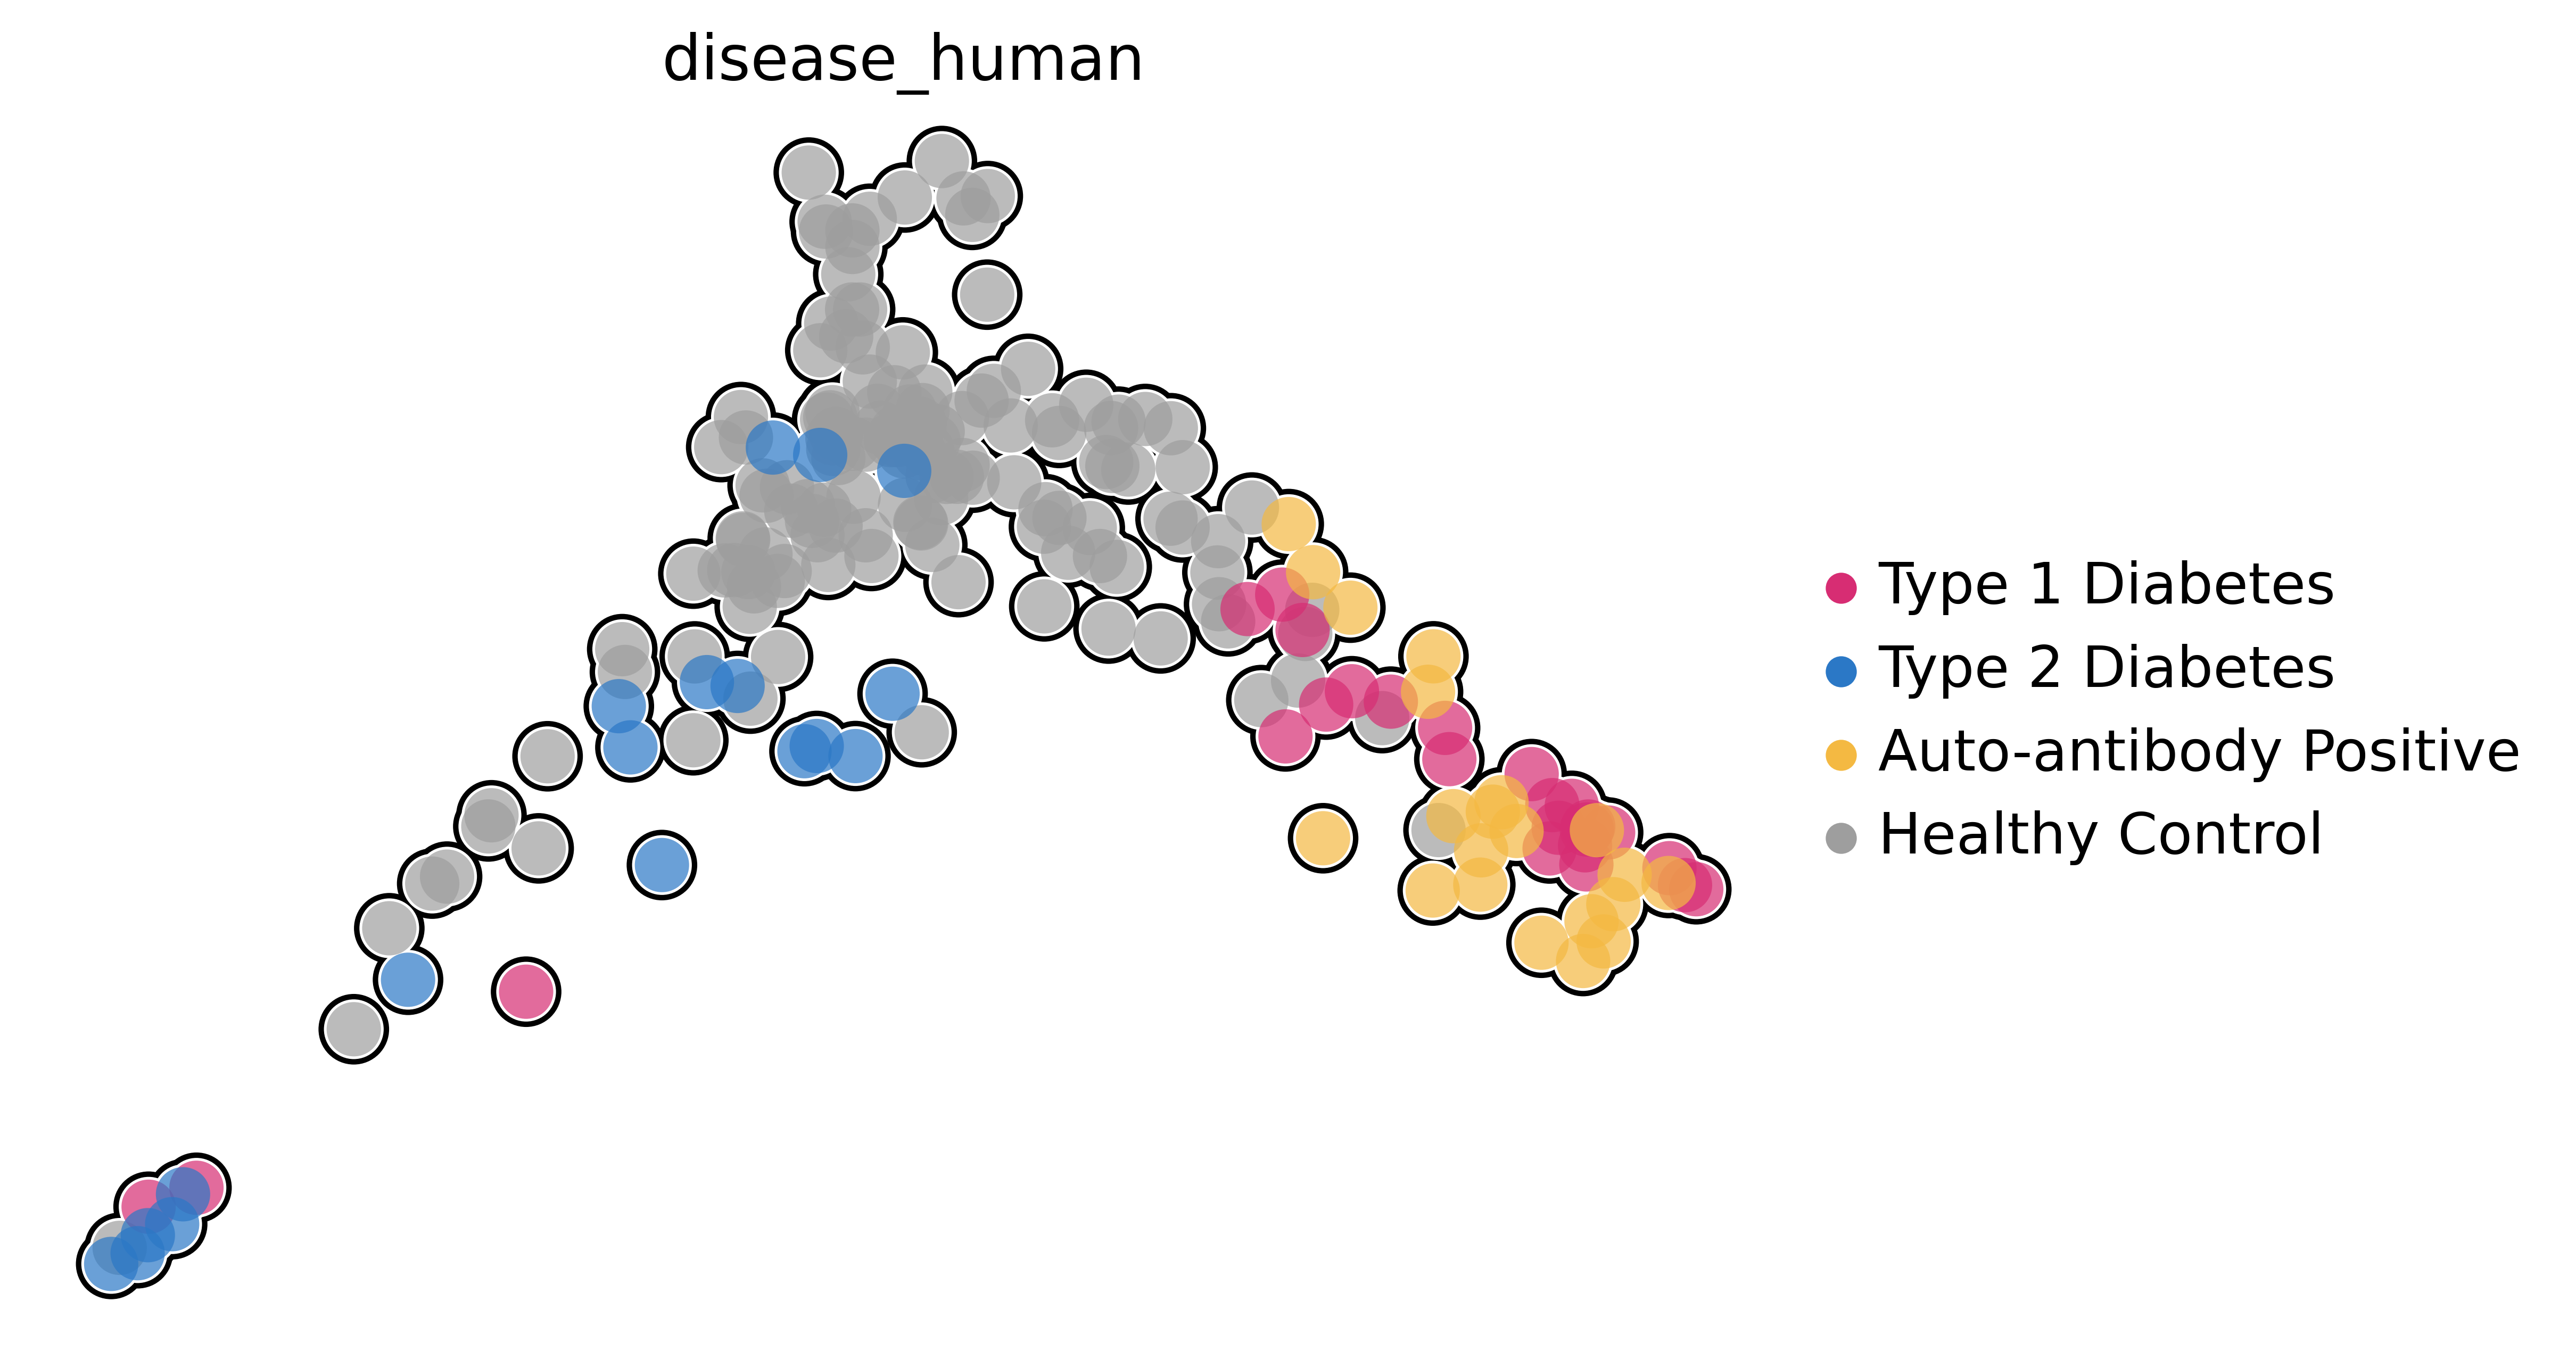

In [245]:
# Define a palette for disease_human to match the provided legend image:
# - Type 1 Diabetes: pink/magenta
# - Type 2 Diabetes: blue
# - Auto-antibody Positive: yellow/orange
# - Healthy: gray

disease_human_palette = {
    "Type 1 Diabetes": "#d72d73",             # pink/magenta: matches legend dot (approx. rgb(215,45,115))
    "Type 2 Diabetes": "#2b78c6",             # blue: matches legend dot (approx. rgb(43,120,198))
    "Auto-antibody Positive": "#f4b942",      # yellow/orange: matches legend dot (approx. rgb(244,185,66))
    "Healthy Control": "#9e9e9e"              # gray: matches legend dot (approx. rgb(158,158,158))
}
sc.pl.diffmap(
    meta_adata,
    color='disease_human',
    size=600,
    sort_order=True,
    add_outline=True,
    frameon=False,
    outline_width=(0.1, 0.05),
    # outline_color=['white', 'black'],
    na_color='lightgray',
    na_in_legend=False,
    palette=disease_human_palette,
    components=["2,3"],
    save='_patient_embedding_diabetes.svg'
)


In [260]:
meta_adata.obs['root_ixs'] = meta_adata.obs['root_ixs'].astype(str)
meta_adata.obs['root_ixs'] = meta_adata.obs['root_ixs'].replace('nan', np.nan)

In [261]:
meta_adata.obs['root_ixs'].unique()

array([nan, '1.0'], dtype=object)

In [274]:
# Plot two layers on a single scanpy diffusion map embedding:
# 1. Plot palantir_pseudotime as a continuous background with sc.pl.diffmap, using show=False and capturing the axis.
# 2. Overlay root_ixs=='1.0' as black dots on the same axes.

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# 1. Palantir pseudotime as background (continuous colormap, all cells)
sc.pl.diffmap(
    meta_adata,
    color='palantir_pseudotime',
    size=600,
    sort_order=True,
    add_outline=True,
    frameon=False,
    outline_width=(0.1, 0.05),
    na_color='lightgray',
    na_in_legend=False,
    cmap='Spectral_r',
    components=["2,3"],
    show=False,
    ax=ax,
)

# 2. Overlay: only root_ixs=='1.0' in black, everything else invisible
sc.pl.diffmap(
    meta_adata[meta_adata.obs['root_ixs'] == '1.0'],
    color='root_ixs',
    size=600,
    add_outline=True,
    frameon=False,
    outline_width=(0.1, 0.01),
    na_color='lightgray',
    na_in_legend=False,
    palette={'1.0': 'black'},
    components=["2,3"],
    show=False,
    ax=ax,
)

plt.tight_layout()
plt.savefig("diffmap_root_pixels_overlay.svg", dpi=300)
plt.close(fig)

n donors: 196
genes present: ['KIAA1324', 'CASC4', 'MARCH6', 'MARCH7', 'IARS', 'EPRS', 'SARS', 'H2AFY']
genes missing: set()


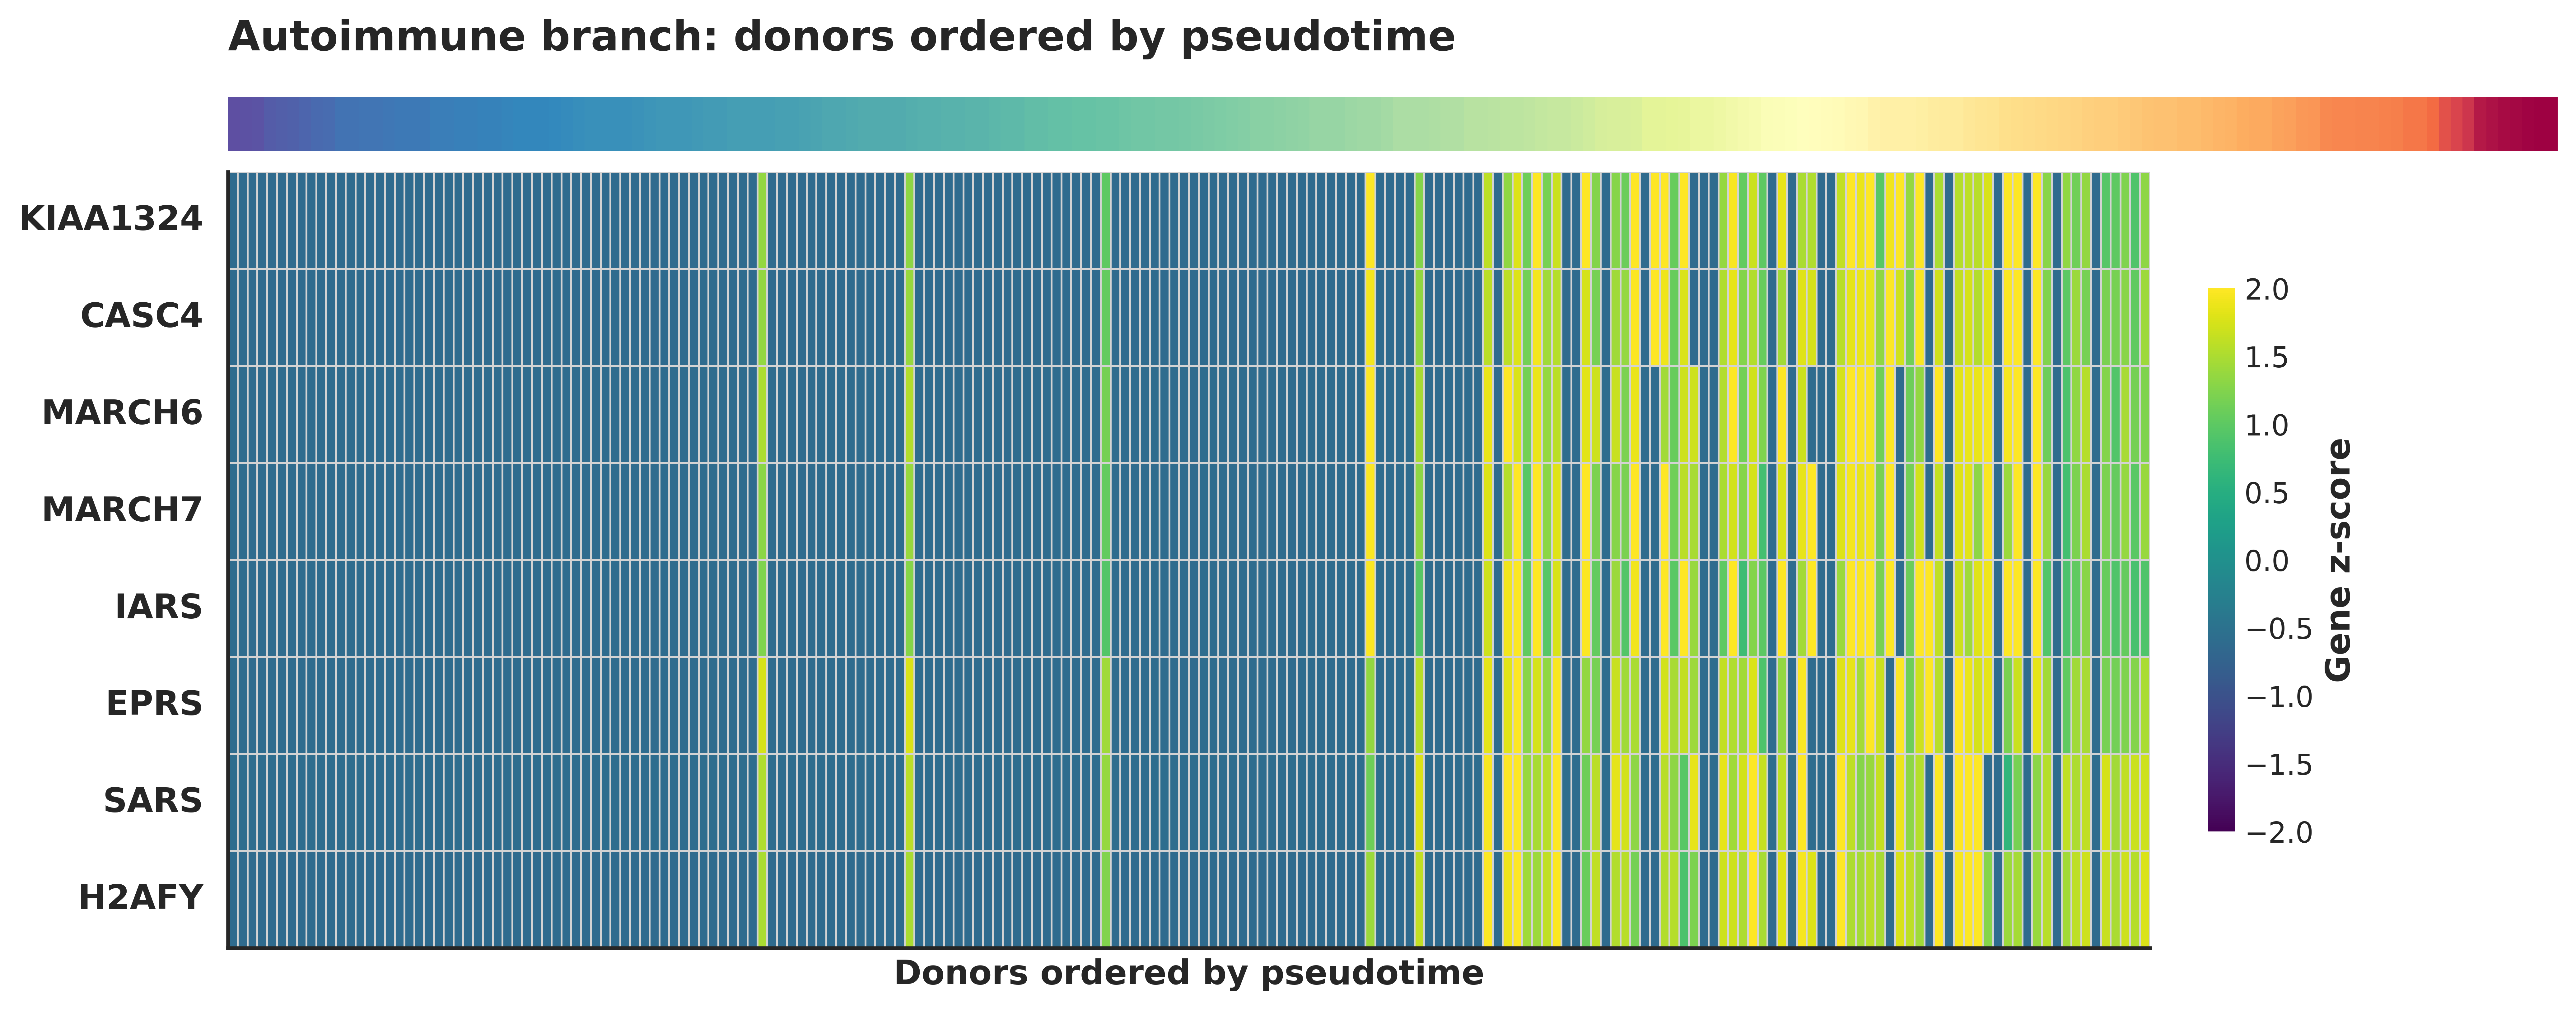

In [245]:
from scipy import sparse
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl

autoimmune_genes = [
    "KIAA1324", "CASC4", "MARCH6", "MARCH7",
    "IARS", "EPRS", "SARS", "H2AFY"
]

# subset branch donors
pb = beta_pb[
    beta_pb.obs["disease_human"].isin(["Healthy Control", "Type 2 Diabetes", "Type 1 Diabetes", "Auto-antibody Positive"])
].copy()

# keep only genes present
autoimmune_genes_present = [g for g in autoimmune_genes if g in pb.var_names]

print("n donors:", pb.n_obs)
print("genes present:", autoimmune_genes_present)
print("genes missing:", set(autoimmune_genes) - set(autoimmune_genes_present))

# sort donors by pseudotime
pb.obs["palantir_pseudotime"] = pd.to_numeric(
    pb.obs["palantir_pseudotime"],
    errors="coerce"
)

pb = pb[
    pb.obs["palantir_pseudotime"].notna()
].copy()

pb = pb[
    pb.obs.sort_values("palantir_pseudotime").index
].copy()

# extract expression
X = pb[:, autoimmune_genes_present].X
if sparse.issparse(X):
    X = X.toarray()

# safety check
if X.shape[0] == 0:
    raise ValueError("No donors left after filtering.")
if X.shape[1] == 0:
    raise ValueError("No selected genes found in pb.var_names.")

# z-score each gene across donors
X_scaled = StandardScaler().fit_transform(X)

heatmap_df = pd.DataFrame(
    X_scaled.T,
    index=autoimmune_genes_present,
    columns=pb.obs_names
)

# pseudotime strip from same pb object
pt = pb.obs["palantir_pseudotime"].values[None, :]

# Restrict pseudotime bar to only the columns in the heatmap (order matches by construction)
num_donors = heatmap_df.shape[1]
pt_restricted = pt[:, :num_donors]  # They should already match, but this explicit

# --- Prettified Heatmap ---

# Set a more appealing style
sns.set_theme(context="notebook", style="white", font_scale=1.1)
mpl.rcParams['axes.linewidth'] = 1.5

fig = plt.figure(figsize=(16, 6), dpi=300)
gs = fig.add_gridspec(2, 1, height_ratios=[0.28, 4], hspace=0.05)

# Top pseudotime colorbar
ax1 = fig.add_subplot(gs[0])
sns.heatmap(
    pt_restricted,
    cmap="Spectral_r",
    cbar=False,
    xticklabels=False,
    yticklabels=False,
    ax=ax1
)
ax1.set_xlim(0, num_donors)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_title("Autoimmune branch: donors ordered by pseudotime", fontsize=16, pad=18, weight='bold', loc='left')

# Heatmap for gene expression
ax2 = fig.add_subplot(gs[1])
cmap = mpl.cm.get_cmap("viridis").copy()
sns.heatmap(
    heatmap_df,
    cmap=cmap,
    center=0,
    vmin=-2,
    vmax=2,
    xticklabels=False,
    yticklabels=heatmap_df.index,
    linewidths=0.5,
    linecolor='lightgrey',
    ax=ax2,
    cbar_kws={
        "label": "Gene z-score",
        "shrink": 0.7,
        "aspect": 20,
        "pad": 0.025,
    }
)

# Beautify colorbar
cbar = ax2.collections[0].colorbar
cbar.set_label("Gene z-score", fontsize=13, weight='bold')
cbar.ax.tick_params(labelsize=11, length=0)
for spine in cbar.ax.spines.values():
    spine.set_visible(False)

# Prettify axes
ax2.set_xlabel("Donors ordered by pseudotime", fontsize=13, weight="bold")
ax2.set_ylabel("")
ax2.tick_params(axis="y", labelsize=12)
ax2.tick_params(axis="x", length=0)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, ha='right', fontsize=13, weight='bold')
sns.despine(ax=ax2)

# Remove figure grid
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.grid(False)

# Save figure as SVG and PNG with dpi 300
fig.savefig("autoimmune_branch_heatmap.svg", format="svg", dpi=300, bbox_inches='tight')
fig.savefig("autoimmune_branch_heatmap.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

n donors: 157
genes present: ['ATP5MD', 'ATP5MPL', 'H3F3A', 'H3F3B', 'H2AFJ', 'HIST1H1C']
genes missing: set()


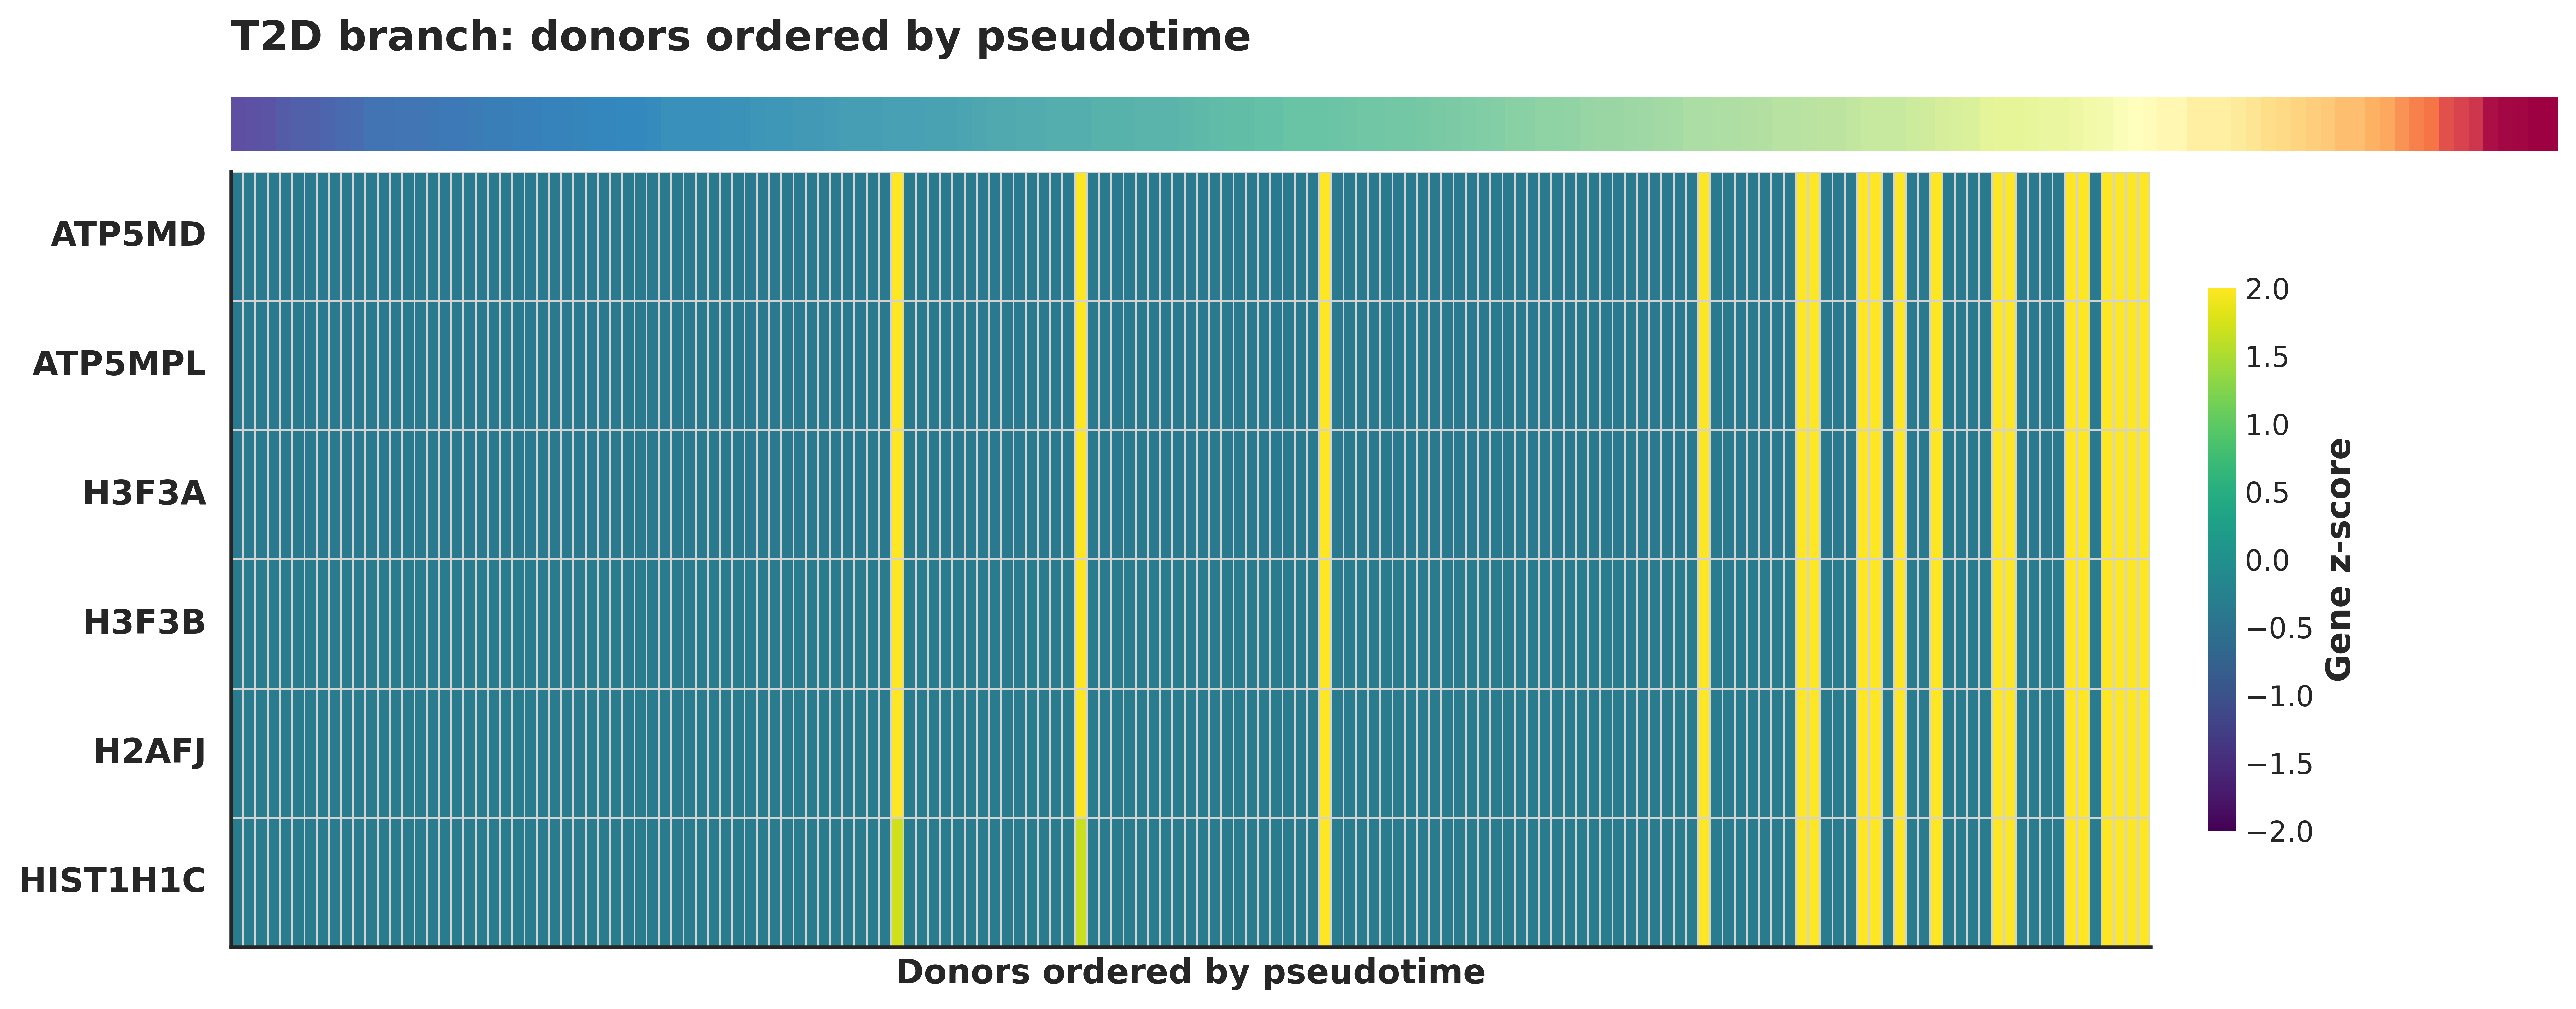

In [246]:
t2d_genes = [
    "ATP5MD",
    "ATP5MPL",
    "H3F3A",
    "H3F3B",
    "H2AFJ",
    "HIST1H1C"
]

# Subset branch donors for T2D analysis
pb = beta_pb[
    beta_pb.obs["disease_human"].isin(["Healthy Control", "Type 2 Diabetes"])
].copy()

# keep only genes present
t2d_genes_present = [g for g in t2d_genes if g in pb.var_names]

print("n donors:", pb.n_obs)
print("genes present:", t2d_genes_present)
print("genes missing:", set(t2d_genes) - set(t2d_genes_present))

# sort donors by pseudotime
pb.obs["palantir_pseudotime"] = pd.to_numeric(
    pb.obs["palantir_pseudotime"],
    errors="coerce"
)

pb = pb[
    pb.obs["palantir_pseudotime"].notna()
].copy()

pb = pb[
    pb.obs.sort_values("palantir_pseudotime").index
].copy()

# extract expression
X = pb[:, t2d_genes_present].X
if sparse.issparse(X):
    X = X.toarray()

# safety check
if X.shape[0] == 0:
    raise ValueError("No donors left after filtering.")
if X.shape[1] == 0:
    raise ValueError("No selected genes found in pb.var_names.")

# z-score each gene across donors
X_scaled = StandardScaler().fit_transform(X)

heatmap_df = pd.DataFrame(
    X_scaled.T,
    index=t2d_genes_present,
    columns=pb.obs_names
)

# pseudotime strip from same pb object
pt = pb.obs["palantir_pseudotime"].values[None, :]

# Restrict pseudotime bar to only the columns in the heatmap (order matches by construction)
num_donors = heatmap_df.shape[1]
pt_restricted = pt[:, :num_donors]  # They should already match, but this explicit

# --- Prettified Heatmap ---

import matplotlib as mpl

# Set a more appealing style
sns.set_theme(context="notebook", style="white", font_scale=1.1)
mpl.rcParams['axes.linewidth'] = 1.5

fig = plt.figure(figsize=(16, 6), dpi=300)
gs = fig.add_gridspec(2, 1, height_ratios=[0.28, 4], hspace=0.05)

# Top pseudotime colorbar
ax1 = fig.add_subplot(gs[0])
sns.heatmap(
    pt_restricted,
    cmap="Spectral_r",
    cbar=False,
    xticklabels=False,
    yticklabels=False,
    ax=ax1
)
ax1.set_xlim(0, num_donors)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_title("T2D branch: donors ordered by pseudotime", fontsize=16, pad=18, weight='bold', loc='left')

# Heatmap for gene expression
ax2 = fig.add_subplot(gs[1])
cmap = mpl.cm.get_cmap("viridis").copy()
sns.heatmap(
    heatmap_df,
    cmap=cmap,
    center=0,
    vmin=-2,
    vmax=2,
    xticklabels=False,
    yticklabels=heatmap_df.index,
    linewidths=0.5,
    linecolor='lightgrey',
    ax=ax2,
    cbar_kws={
        "label": "Gene z-score",
        "shrink": 0.7,
        "aspect": 20,
        "pad": 0.025,
    }
)

# Beautify colorbar
cbar = ax2.collections[0].colorbar
cbar.set_label("Gene z-score", fontsize=13, weight='bold')
cbar.ax.tick_params(labelsize=11, length=0)
for spine in cbar.ax.spines.values():
    spine.set_visible(False)

# Prettify axes
ax2.set_xlabel("Donors ordered by pseudotime", fontsize=13, weight="bold")
ax2.set_ylabel("")
ax2.tick_params(axis="y", labelsize=12)
ax2.tick_params(axis="x", length=0)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, ha='right', fontsize=13, weight='bold')
sns.despine(ax=ax2)

# Remove figure grid
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.grid(False)

# Save figure as SVG and PNG with dpi 300
fig.savefig("t2d_branch_heatmap.svg", format="svg", dpi=300, bbox_inches='tight')
fig.savefig("t2d_branch_heatmap.png", format="png", dpi=300, bbox_inches='tight')
plt.show()